In [1]:
import numpy as np 
import rebound
import os
import matplotlib.pyplot as plt
import dill
import pandas as pd

In [2]:
tess_offset =  2457000

# Definitions

In [3]:
def mean_anomaly(t, omega, e, Tc, P):
    """
    Calculate mean anomaly M at time t, given:
    - omega: argument of periastron (radians)
    - e: eccentricity
    - Tc: time of inferior conjunction (transit)
    - P: orbital period
    
    Converts Tc to periastron passage time tau using the formula:
    2*pi*(Tc - tau)/P = E0 - e*sin(E0)
    with E0 = 2 * arctan(sqrt((1-e)/(1+e)) * tan(pi/2 - omega/2))
    
    Returns mean anomaly M in radians [0, 2pi).
    """
    # Compute E0 from e and omega
    E0 = 2 * np.arctan( np.sqrt((1 - e) / (1 + e)) * np.tan(np.pi/4 - omega/2) )
    E0 = E0 % (2 * np.pi)

    # Compute time of periastron passage tau
    tau = Tc - (P / (2 * np.pi)) * (E0 - e * np.sin(E0))
    # print(tau[0], omega[0], e[0], Tc[0], P[0] )
    # print(f'tau: {tau[0]}') 
    # print(f'omega: {omega[0]}')
    # print(f'e: {e[0]}')
    # print(f'Tc: {Tc[0]}')
    # print(f'P: {P[0]}')

    # Compute mean anomaly at time t
    M = (2 * np.pi / P) * (t - tau)
    M = M % (2 * np.pi)

    return M


# Data

In [4]:
### get the posterior data
# file_name = '1339_jnkep_fit_1339-2000burn-2000step-emax0.5.pkl'
file_name = '1339_jnkep_nburn-1000_nsteps-1000_hessian_tree-11_accept-95_emax-0.5.pkl'


working_dir = os.getcwd()
data_dir = os.path.join(working_dir, "data")

file_path = os.path.join(data_dir, file_name)

In [5]:
with open(file_name, "rb") as f:
    mcmc = dill.load(f)
mcmc.print_summary()
print(mcmc)

posterior = mcmc.get_samples(group_by_chain=True)  # shape: (num_chains, num_samples, ...)
print({k: v.shape for k, v in posterior.items()})


                      mean       std    median      5.0%     95.0%     n_eff     r_hat
 ecosw_scaled[0]      0.33      0.07      0.32      0.22      0.43    157.16      1.03
 ecosw_scaled[1]      0.35      0.06      0.34      0.25      0.44    157.72      1.03
 esinw_scaled[0]      0.36      0.09      0.36      0.22      0.51    151.05      1.05
 esinw_scaled[1]      0.38      0.08      0.38      0.26      0.51    150.82      1.05
period_scaled[0]      0.50      0.00      0.50      0.50      0.50    214.86      1.03
period_scaled[1]      0.50      0.00      0.50      0.50      0.50    350.97      1.03
 pmass_scaled[0]      0.02      0.00      0.02      0.01      0.02    253.05      1.03
 pmass_scaled[1]      0.01      0.00      0.01      0.01      0.01    195.19      1.03
   tic_scaled[0]      0.48      0.00      0.48      0.48      0.49    181.14      1.04
   tic_scaled[1]      0.51      0.01      0.51      0.50      0.53    234.54      1.05

Number of divergences: 30
{'ecc': (8, 100

In [6]:
good_chain_idxs = [0,1,2,3,4,5,6,7]

samples_filtered = {
    k: v[good_chain_idxs, ...] for k, v in posterior.items()
}
# print(samples_filtered)
samples = {
    k: v.reshape(-1, *v.shape[2:]) for k, v in samples_filtered.items()
}

# Shape of samples
print({k: v.shape for k, v in samples.items()})


{'ecc': (8000, 2), 'ecosw': (8000, 2), 'ecosw_scaled': (8000, 2), 'ediff': (8000,), 'esinw': (8000, 2), 'esinw_scaled': (8000, 2), 'period': (8000, 2), 'period_scaled': (8000, 2), 'pmass': (8000, 2), 'pmass_scaled': (8000, 2), 'tcmodel': (8000, 39), 'tic': (8000, 2), 'tic_scaled': (8000, 2)}


In [7]:
### conversions
solar_mass_2_kg = 1.989e30 # [kg per solar mass]
d_2_s = 86400 # [seconds per day]

### system constants 
m_star = 0.81  # [solar mass]

from astropy import units as u
from astropy import constants as c
G_const_si = c.G
G_const = c.G.to(u.AU**3 / u.M_sun / u.day**2).value


### posterior samples 
ecosw_c = samples["ecosw"][:, 0]
esinw_c = samples["esinw"][:, 0]
# e_c = samples["ecc"][:,0]
P_c = samples["period"][:,0] # [days]
Tc_c = samples["tic"][:,0] # [days]
m_c = samples["pmass"][:,0] # [solar mass]

ecosw_d = samples["ecosw"][:, 1]
esinw_d = samples["esinw"][:, 1]
# e_d = samples["ecc"][:,1]
P_d = samples["period"][:,1] # [days]
Tc_d = samples["tic"][:,1] # [days]
m_d = samples["pmass"][:,1] # [solar mass]  

### calculated params
a_c = np.array(((G_const*m_star*P_c**2)/(4*np.pi**2))**(1.0/3.)) # [AU]
a_d = np.array(((G_const*m_star*P_d**2)/(4*np.pi**2))**(1./3.)) # [AU]

e_c = np.sqrt(ecosw_c**2 + esinw_c**2)
e_d = np.sqrt(ecosw_d**2 + esinw_d**2)
omega_c = np.arctan2(esinw_c, ecosw_c) # [rad]
omega_d = np.arctan2(esinw_d, ecosw_d) # [rad]

# times = np.array([1980.] * len(omega_c))
times = Tc_d
ref_time = 0.0 # set to simulation start time

Mean_anomaly_c = mean_anomaly(ref_time, omega_c, e_c, Tc_c, P_c)
Mean_anomaly_d = mean_anomaly(ref_time, omega_d, e_d, Tc_d, P_d)

### keep Omega constant
value_Omega_c = 0  # [deg]
Omega_c = np.full_like(omega_c, np.radians(value_Omega_c))
value_Omega_d = 0 # [deg]
Omega_d = np.full_like(omega_d, np.radians(value_Omega_d))

pomega_c = omega_c + Omega_c
pomega_d = omega_d + Omega_d
lambda_c = omega_c + Omega_c + Mean_anomaly_c
lambda_d = omega_d + Omega_d + Mean_anomaly_d

# Set fixed inclination (e.g. edge-on)
inc_c = [np.pi / 2] * len(a_c)
inc_d = [np.pi / 2] * len(a_d)

print(a_c)
print(m_c)
print(np.array(Omega_c))

[0.17053477 0.17053477 0.17053476 ... 0.17053413 0.17053482 0.1705335 ]
[1.32594778e-05 1.32760388e-05 1.31379475e-05 ... 1.42283043e-05
 1.88686045e-05 1.86341822e-05]
[0. 0. 0. ... 0. 0. 0.]


In [8]:
r_apo_c = a_c * (1 + e_c)
r_peri_d = a_d * (1 - e_d)
initially_crossed=[]
for i in range(len(r_apo_c)):
    r_apo = r_apo_c[i]
    r_peri = r_peri_d[i]
    if r_peri < r_apo:
        initially_crossed.append(i)

print(f'Systems where initial posterior state has r_peri_d < r_apo_c: {len(initially_crossed)}')

Systems where initial posterior state has r_peri_d < r_apo_c: 7322


In [9]:
# Set parameters (fixed values from literature) Polanski, orell-miquel
from astropy.constants import M_jup, M_sun
mass_b = 0.0302 * (M_jup / M_sun)
a_b = 0.079
e_b = 0.0
omega_b = np.radians(90.)
Omega_b = 0.0 # assume 0
inc_b = np.pi / 2
Tc_b = 2458715.35572 - tess_offset
P_b = 8.8803232



mass_e = 0.3590 * (M_jup / M_sun)  # MJup to Msun
a_e = 0.400
e_e = 0.0
omega_e = np.radians(230.0)
Omega_e = 0.0  # Assume 0 for simplicity
inc_e = np.pi / 2  # edge-on
Tc_e = 2459044.0 - tess_offset
P_e = 101.5

# Reference time = same as for other planets
# t_ref = times[i]  # or pick a fixed time like 2459000

M_e = mean_anomaly(np.median(Tc_d), omega_e, e_e, Tc_e, P_e)
M_b = mean_anomaly(np.median(Tc_d), omega_b, e_b, Tc_b, P_b)

pomega_b = omega_b + Omega_b
pomega_e = omega_e + Omega_e
lambda_b = omega_b + Omega_b + M_b
lambda_e = omega_e + Omega_e + M_e

# Check stability
only return true if no encounter, escape, or exception

In [10]:
def simulate_draw(i, m_star, a_c, a_d, m_c, m_d, e_c, e_d, inc_c, inc_d,
                  Omega_c, Omega_d, omega_c, omega_d, M_c, M_d,
                  tmax=1e6):
    """
    Simulate a single posterior draw for two planets and return True if stable.
    Assumes units: AU, Msun, days.
    dt in years?
    """
    sim = rebound.Simulation()
    sim.units = ('AU', 'day', 'Msun')
    sim.G = G_const  # Set your custom G if using AU/day²/Msun

    # Central star
    sim.add(m=m_star)

    # Planet b
    sim.add(m=mass_b,
        a=a_b,
        e=e_b,
        inc=inc_b,
        Omega=Omega_b,
        omega=omega_b,
        M=M_b)

    # Planet c
    sim.add(m=m_c[i],
            a=a_c[i],
            e= e_c[i],
            inc=inc_c[i],
            Omega=Omega_c[i],
            omega= omega_c[i],
            M=M_c[i])

    # Planet d
    sim.add(m=m_d[i],
            a=a_d[i],
            e= e_d[i],
            inc=inc_d[i],
            Omega=Omega_d[i],
            omega=omega_d[i],
            M=M_d[i])

    # Planet e
    sim.add(m=mass_e,
        a=a_e,
        e=e_e,
        inc=inc_e,
        Omega=Omega_e,
        omega=omega_e,
        M=M_e)

    
    sim.move_to_com()
    sim.integrator = "whfast"
    dt = P_b/20
    sim.dt = dt

    # Optional: encounter detection
    r_hill = a_c[i] * np.sqrt(m_c[i] / (3*m_star))
    sim.exit_min_distance = r_hill  # [AU], or adjust to Roche limit

    try:
        Noutputs =  20000 #int(tmax / dt) # number of points along orbit

        # arrays to store positions
        Nplanets = len(sim.particles) - 1  # skip star
        x = np.zeros((Noutputs, Nplanets))
        y = np.zeros((Noutputs, Nplanets))
        z = np.zeros((Noutputs, Nplanets))
        e = np.zeros((Noutputs, Nplanets))
        a = np.zeros((Noutputs, Nplanets))
        inc = np.zeros((Noutputs, Nplanets))
        # choose times: 0 → tmax
        times = np.linspace(0, tmax, Noutputs)

        # dt_output = tmax / Noutputs
        for k, t in enumerate(times):
            sim.integrate(t)
        
            for j in range(Nplanets):
                p = sim.particles[j+1]  # skip star at index 0
                x[k,j] = p.x
                y[k,j] = p.y
                z[k,j] = p.z 
                e[k,j] = p.e
                a[k,j] = p.a
                inc[k,j] = p.inc
                
        # sim.integrate(tmax)

        
        if (e[:,0] >= 1.0).any() or (e[:,1] >= 1.0).any() or (e[:,2]>=1.0).any() or (e[:,3]>= 1.0).any():
            note = "escape or unbound"
            print(note)
            return False, note, sim, x, y, z, e, a, inc

        cross_times = []
        for k in range(Noutputs):
            Q_c = a[k,1] * (1 + e[k,1]) # apo for inner planet 
            q_d = a[k,2] * (1 - e[k,2]) # peri for outer planet
            
            if q_d < Q_c:
                cross_times.append(times[k])
                # note = "orbit crossing"
                # print(note)
                # return False, note, sim, x, y, z, e, a, inc
        if cross_times:
            note = "orbit crossing"
            print(note)
            return False, note, sim, x, y, z, e, a, inc
        else:        
            note='stable'
            print(note)
            return True, note, sim, x, y, z, e, a, inc

    except rebound.Encounter:
        note = f"encounter"
        print(note)
        return False, note, sim, x, y, z, e, a, inc
    


In [14]:
n_draws = 5  # or whatever number feels fast enough
N_total = len(P_c)  # assuming all arrays are same length

# Choose `n_draws` unique random indices
random_indices = np.random.choice(N_total, size=n_draws, replace=False)

# random_indices = [4815, 3739, 445, 5777]
# random_indices=[1823]
# random_indices = [1]

print(random_indices)

[1682  948 7610 3535   62]


28580749.51171875
escape or unbound
[[ 0.079       0.17053397  0.20746341  0.4       ]
 [ 0.07900493  0.17048245  0.20751633  0.39999599]
 [ 0.07900612  0.17050508  0.20732854  0.40001524]
 ...
 [ 0.0721859  -0.52042167 -0.70608497 -0.42664849]
 [ 0.0721859  -0.52042167 -0.70608497 -0.42664849]
 [ 0.0721859  -0.52042167 -0.70608497 -0.42664849]]
[[0.00000000e+00 3.55073571e-01 3.05821896e-01 0.00000000e+00]
 [1.29130719e-03 3.54947854e-01 3.05424933e-01 3.81016485e-04]
 [2.34463569e-03 3.55205513e-01 3.06679083e-01 4.50983710e-04]
 ...
 [5.90731739e-01 4.90055691e+02 4.93578754e+02 1.40685761e+00]
 [5.90731739e-01 4.90055691e+02 4.93578754e+02 1.40685744e+00]
 [5.90731739e-01 4.90055692e+02 4.93578753e+02 1.40685728e+00]]


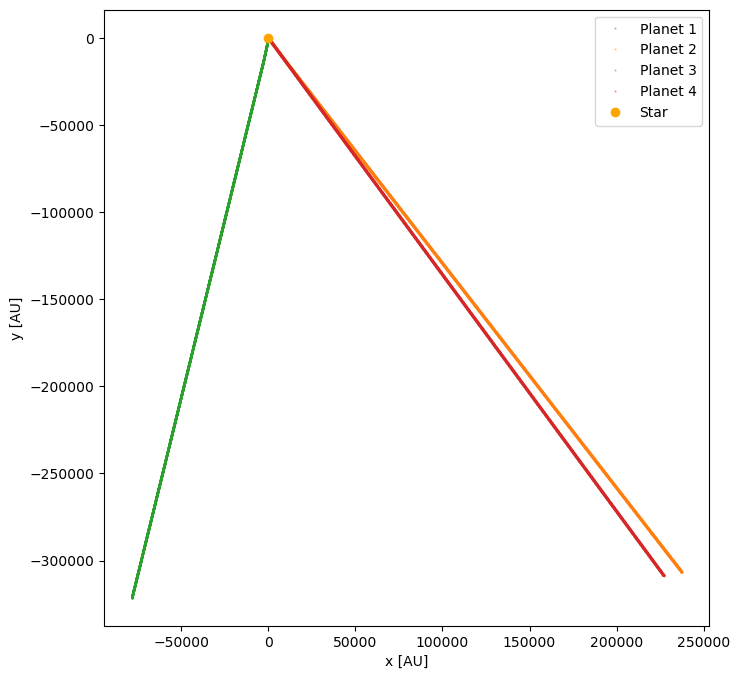

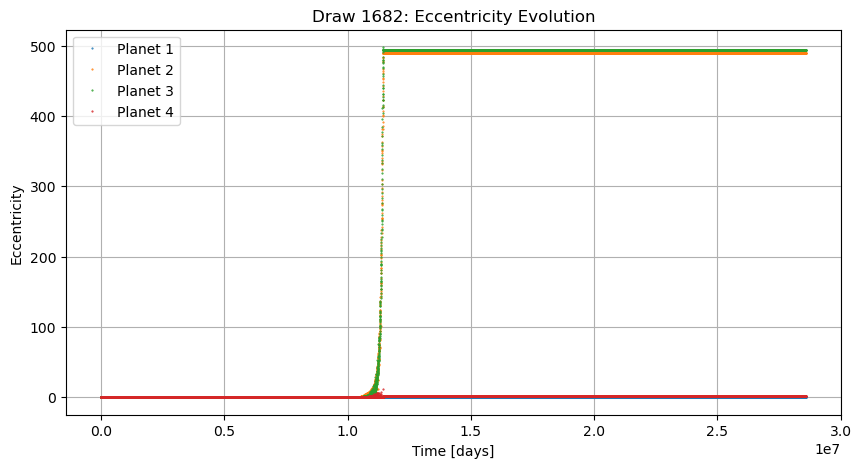

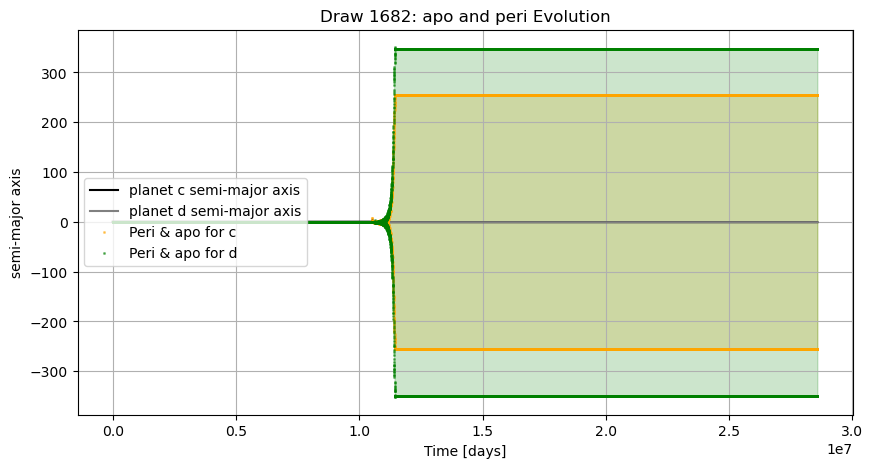

[ 2.31086076e-01  2.30994828e-01  2.31069428e-01 ... -2.55556025e+02
 -2.55556025e+02 -2.55556025e+02]
[1.44016559e-01 1.44135667e-01 1.43745213e-01 ... 3.47802454e+02
 3.47802454e+02 3.47802454e+02]
orbit crossing
[[0.079      0.17053421 0.20746399 0.4       ]
 [0.07899872 0.17052344 0.20751889 0.39999765]
 [0.0789988  0.17054495 0.20741433 0.40000438]
 ...
 [0.07899915 0.17054581 0.20745982 0.40000083]
 [0.07899758 0.17051296 0.20756963 0.39999662]
 [0.07899941 0.17050623 0.20760661 0.39999426]]
[[0.00000000e+00 2.74930805e-01 2.36144066e-01 1.80845711e-16]
 [7.34740986e-04 2.75129399e-01 2.35597273e-01 2.08781979e-04]
 [1.44791802e-03 2.75154178e-01 2.36377636e-01 2.75705386e-04]
 ...
 [1.86624472e-02 2.70507306e-01 2.20269367e-01 1.56287327e-02]
 [1.83626833e-02 2.70815584e-01 2.19342358e-01 1.56070112e-02]
 [1.77637700e-02 2.71254347e-01 2.18353937e-01 1.56370411e-02]]


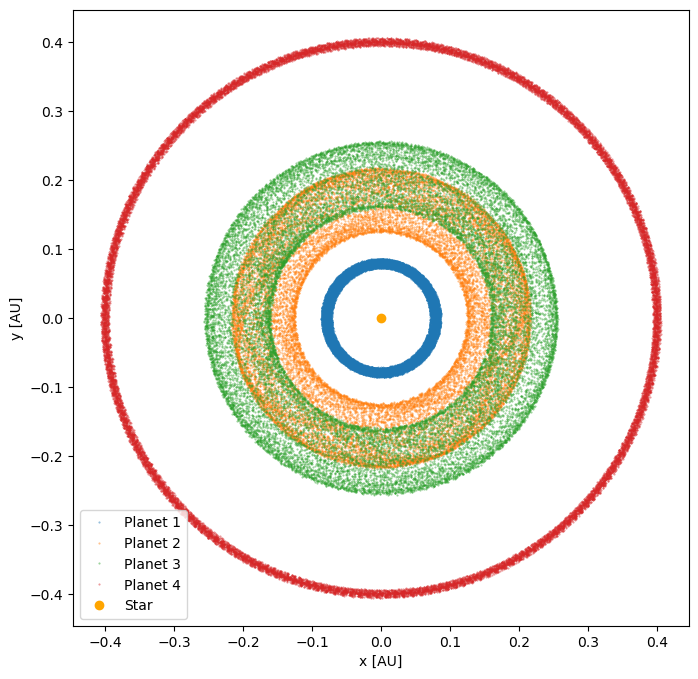

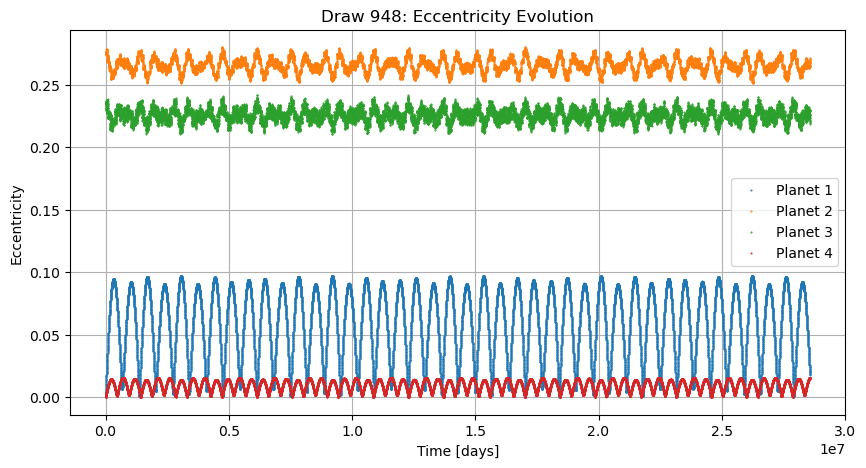

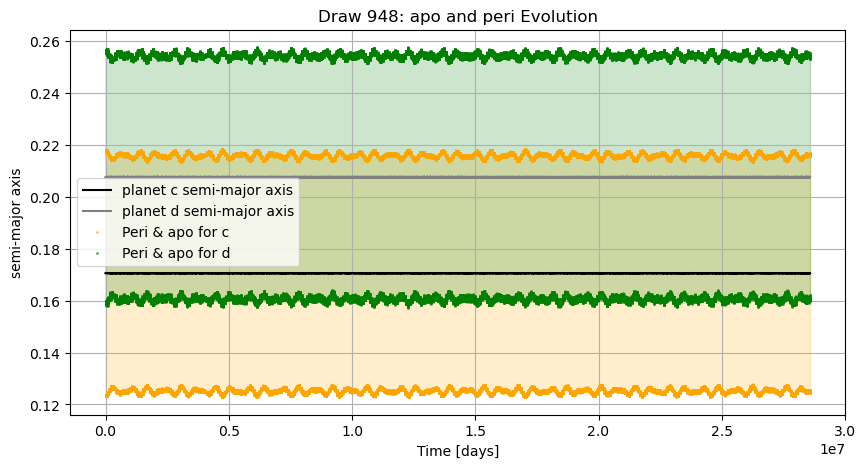

[0.21741932 0.21743945 0.2174711  ... 0.2166797  0.21669052 0.21675679]
[0.1584726  0.15862801 0.15838622 ... 0.16176278 0.16204082 0.16227489]
stable
[[0.079      0.17053503 0.20746194 0.4       ]
 [0.07899951 0.17051783 0.20744505 0.40000185]
 [0.07899994 0.17051861 0.2074266  0.40000236]
 ...
 [0.07900041 0.17051143 0.20746853 0.4000013 ]
 [0.07900014 0.17055551 0.20746331 0.39999842]
 [0.07899937 0.17054865 0.20743909 0.39999995]]
[[0.00000000e+00 5.01177553e-03 3.42962006e-03 0.00000000e+00]
 [4.66184214e-05 5.45824262e-03 1.39242367e-03 8.78135758e-06]
 [2.56609303e-05 5.27212760e-03 2.36069172e-03 5.78917832e-06]
 ...
 [5.25012098e-04 4.62894410e-03 3.77405531e-03 8.78751530e-05]
 [4.92680720e-04 4.31355181e-03 2.78787175e-03 8.28623735e-05]
 [4.98776907e-04 4.32886803e-03 4.10589217e-03 8.32348323e-05]]


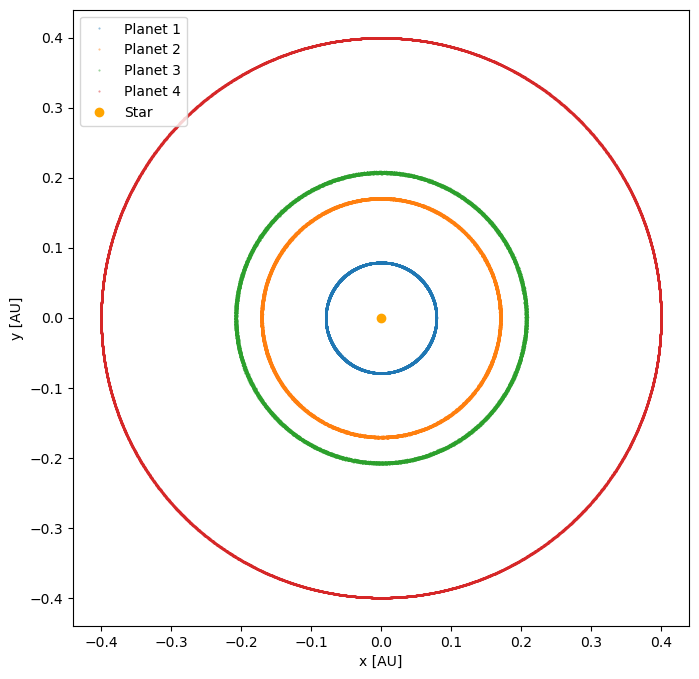

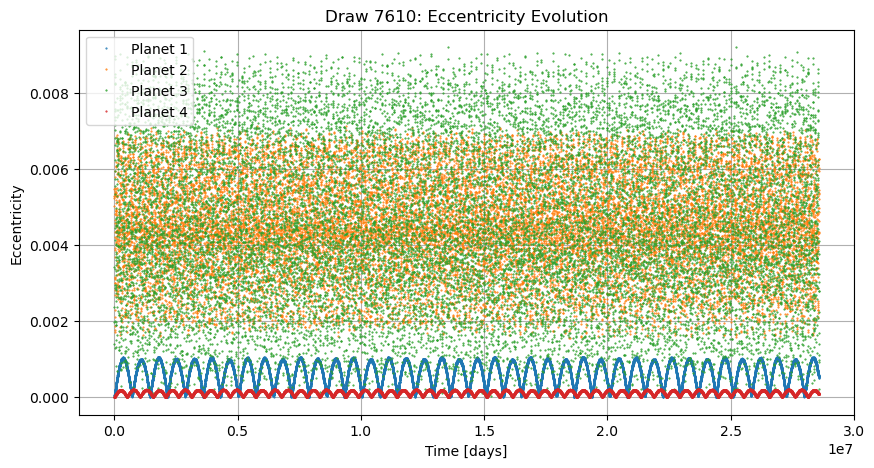

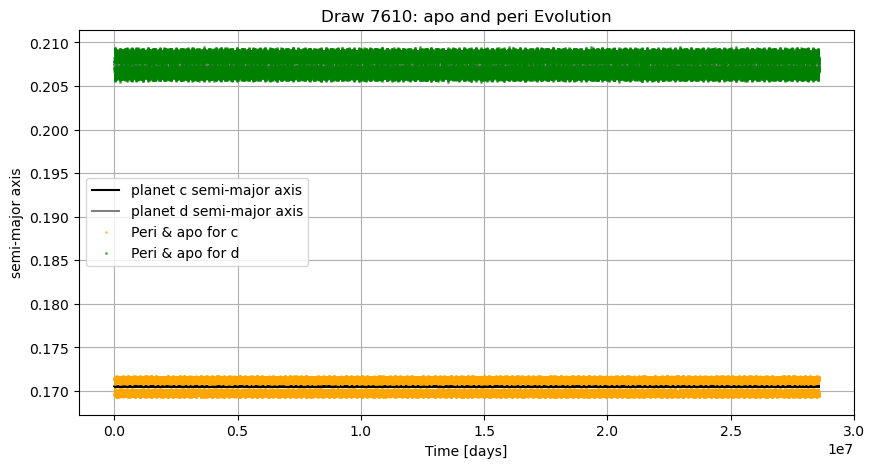

[0.17138971 0.17144856 0.1714176  ... 0.17130072 0.17129121 0.17128693]
[0.20675042 0.2071562  0.20693693 ... 0.20668553 0.20688492 0.20658737]
orbit crossing
[[0.079      0.17053436 0.20746331 0.4       ]
 [0.07900013 0.17050854 0.20754969 0.39999359]
 [0.07900201 0.17051672 0.20743816 0.40000225]
 ...
 [0.07900129 0.17050233 0.20764353 0.39998619]
 [0.07899949 0.17055095 0.20743642 0.39999931]
 [0.07900098 0.170549   0.2076833  0.39997515]]
[[0.00000000e+00 2.66350120e-01 2.28929505e-01 4.42801582e-17]
 [7.51553957e-04 2.66461642e-01 2.27774384e-01 1.94325217e-04]
 [1.35146678e-03 2.66441603e-01 2.28820784e-01 2.87605537e-04]
 ...
 [8.47578160e-03 2.60765796e-01 2.20242384e-01 1.31120080e-02]
 [8.18407304e-03 2.60632125e-01 2.21941014e-01 1.31706224e-02]
 [7.59719554e-03 2.60305830e-01 2.19478100e-01 1.31881329e-02]]


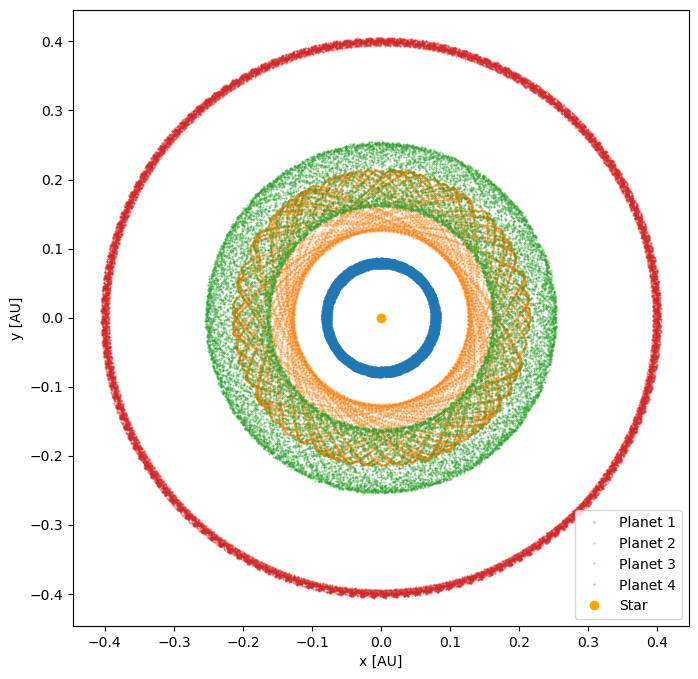

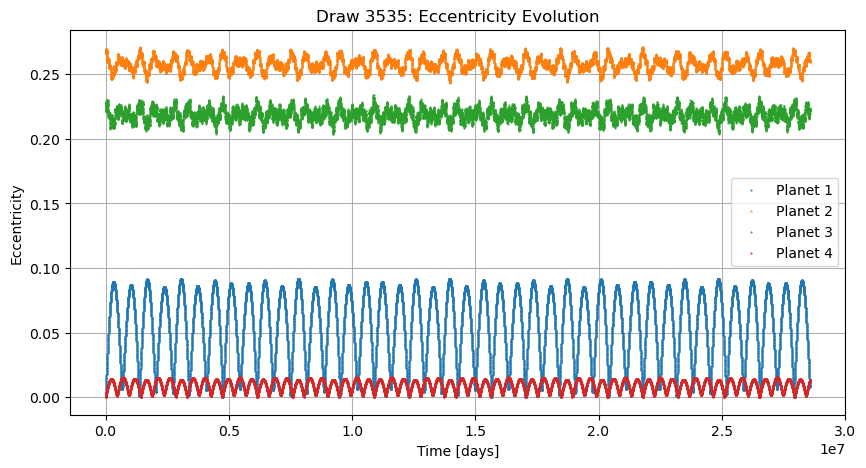

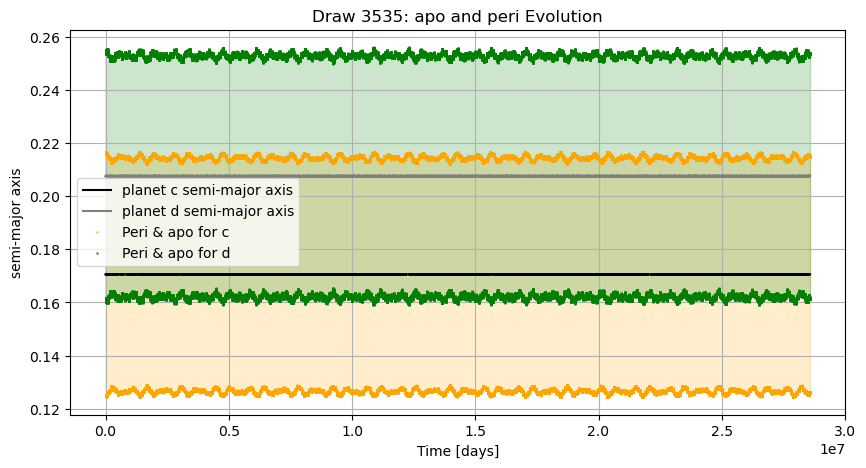

[0.2159562  0.21594253 0.21594946 ... 0.21496351 0.215002   0.2149439 ]
[0.15996884 0.16027518 0.159972   ... 0.16191162 0.16139777 0.16210136]
stable
[[0.079      0.17053443 0.20746318 0.4       ]
 [0.07899958 0.17051616 0.20745056 0.40000172]
 [0.07900001 0.17051846 0.20743285 0.40000173]
 ...
 [0.07899984 0.17051409 0.20748501 0.40000092]
 [0.07899978 0.1705048  0.20754719 0.39999902]
 [0.07899952 0.17053623 0.20741167 0.40000178]]
[[0.00000000e+00 5.99397980e-02 5.19863553e-02 0.00000000e+00]
 [5.89768734e-05 6.00960284e-02 5.19286351e-02 2.09460460e-05]
 [1.62979075e-04 5.99427433e-02 5.17618831e-02 3.62334750e-05]
 ...
 [1.37962395e-03 5.97558821e-02 5.09415331e-02 1.70997547e-03]
 [1.44037427e-03 5.95019018e-02 5.04594518e-02 1.70571234e-03]
 [1.52604035e-03 5.90069319e-02 5.22959009e-02 1.71987216e-03]]


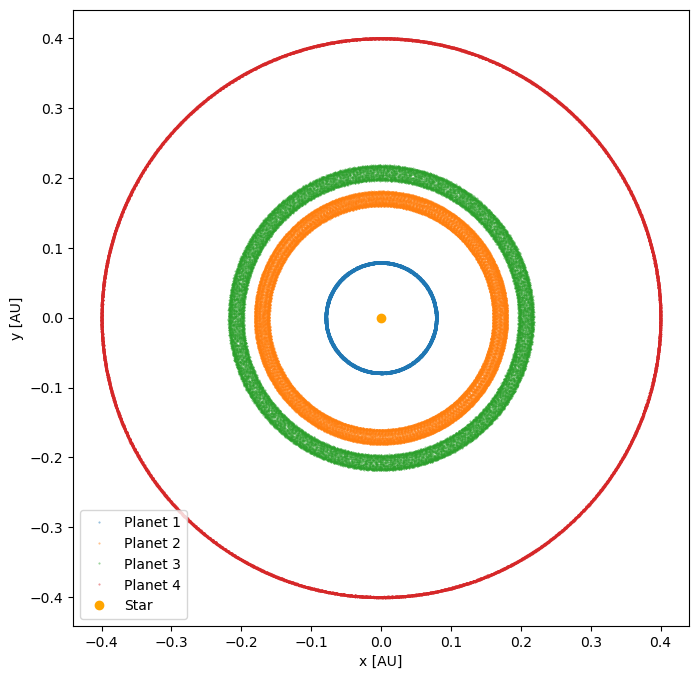

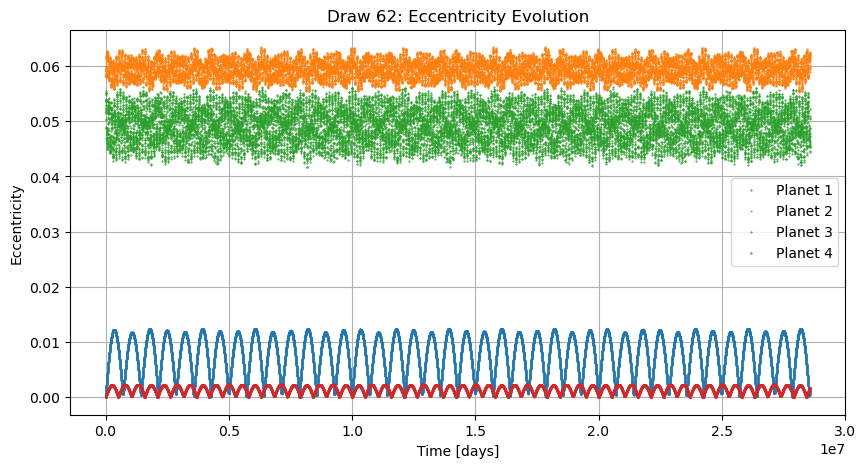

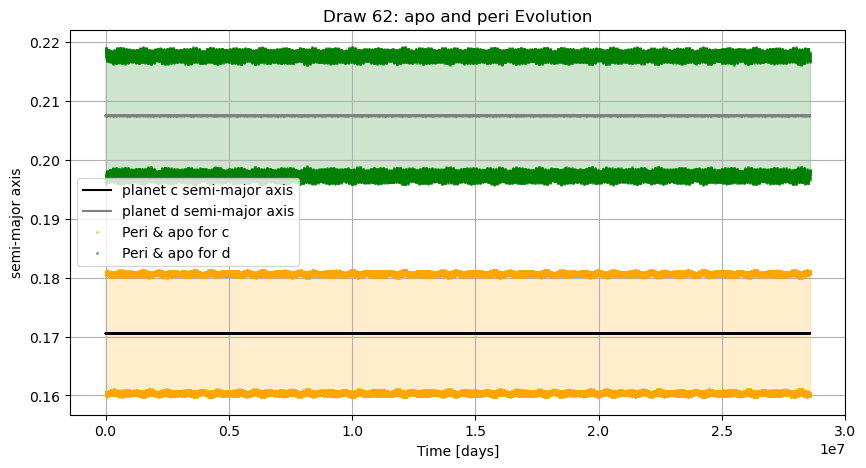

[0.18075623 0.18076351 0.18073981 ... 0.18070331 0.18065016 0.18059905]
[0.19667792 0.19667793 0.19669574 ... 0.1969154  0.19707447 0.19656489]
[False, False, True, False, True]
['escape or unbound', 'orbit crossing', 'stable', 'orbit crossing', 'stable']
[1682, 948, 7610, 3535, 62]


In [15]:
tmax = 1e6 * np.median(P_c)
print(tmax)
draw_idx = []
results = []
notes = []
sims = []

master_data = []
os.makedirs("sim_details", exist_ok=True)

for i in random_indices:
    stable, note, sim, x, y, z, e, a, inc = simulate_draw(
        i=i,
        m_star=m_star,
        a_c=a_c, a_d=a_d,
        m_c=m_c, m_d=m_d,
        e_c=e_c, e_d=e_d,
        inc_c=inc_c, inc_d=inc_d,
        Omega_c=Omega_c, Omega_d=Omega_d,
        omega_c=omega_c, omega_d=omega_d,
        M_c=Mean_anomaly_c, M_d=Mean_anomaly_d,
        tmax = tmax
    )
    draw_idx.append(i)
    results.append(stable)
    notes.append(note)
    sims.append(sim)
    # rebound.OrbitPlotSet(sim)
    print(a)
    print(e)

    # SAVE DATA
    # Create per-simulation dataframe for integration steps
    times = np.linspace(0, tmax, len(e))  # len(e) is number of timesteps
    step_df = pd.DataFrame({"time_days": times})
    
    Nplanets = e.shape[1]  # number of planets
    
    for p in range(Nplanets):
        step_df[f"x_p{p+1}"] = x[:, p]
        step_df[f"y_p{p+1}"] = y[:, p]
        step_df[f"z_p{p+1}"] = z[:, p]
        step_df[f"e_p{p+1}"] = e[:, p]
        step_df[f"a_p{p+1}"] = a[:, p]
        step_df[f"inc_p{p+1}"] = inc[:, p]
    
    # # Save per-simulation dataframe
    # step_filename = f"sim_details/sim_{i}.csv"
    # step_df.to_csv(step_filename, index=False)

    # # Add a row to master dataframe list
    # master_data.append({
    #     "draw_index": i,
    #     "stable": stable,
    #     "note": note,
    #     "m_b": mass_b, "a_b": a_b, "e_b": e_b, "inc_b": inc_b, "Omega_b": Omega_b, "omega_b": omega_b, "M_b": M_b,
    #     "m_c": m_c[i], "a_c": a_c[i], "e_c": e_c[i], "inc_c": inc_c[i], "Omega_c": Omega_c[i], "omega_c": omega_c[i], "M_c": Mean_anomaly_c[i],
    #     "m_d": m_d[i], "a_d": a_d[i], "e_d": e_d[i], "inc_d": inc_d[i], "Omega_d": Omega_d[i], "omega_d": omega_d[i], "M_d": Mean_anomaly_d[i],
    #     "m_e": mass_e, "a_e": a_e, "e_e": e_e, "inc_e": inc_e, "Omega_e": Omega_e, "omega_e": omega_e, "M_e": M_e,
    #     "detail_file": step_filename
    # })
    



    # PLOTS
    # orbit plot
    plt.figure(figsize=(8,8))
    Nplanets = len(sim.particles) - 1  # skip star
    for j in range(Nplanets):
        plt.plot(x[:,j], z[:,j], '.', markersize=1, alpha=0.5, label=f'Planet {j+1}')
    plt.plot(0,0,'o', color='orange', label='Star')
    plt.gca().set_aspect('equal', 'box')
    plt.xlabel('x [AU]')
    plt.ylabel('y [AU]')
    plt.legend()
    plt.show()

    # eccentricity plot 
    # --- Eccentricity evolution plot ---
    plt.figure(figsize=(10,5))
    times = np.linspace(0, tmax, len(e))
    for j in range(Nplanets):
        plt.plot(times, e[:,j], '.', markersize=1, label=f'Planet {j+1}')
    plt.xlabel('Time [days]')
    plt.ylabel('Eccentricity')
    plt.title(f"Draw {i}: Eccentricity Evolution")
    plt.legend()
    plt.grid(True)
    plt.show()

    # plt.figure(figsize=(10,5))
    # for j in range(Nplanets):
    #     plt.plot(times, a[:,j], '.', markersize=1, label=f'Planet {j+1}')
    # plt.title(f'Draw {i}: semi-major axis Evolution')
    # plt.xlabel('Time [days]')
    # plt.ylabel('semi-major axis')
    # plt.legend()
    # plt.grid(True)
    # plt.show()


    # plt.figure(figsize=(10,5))
    peri_c = a[:,1] * (1 - e[:,1])
    apo_c = a[:,1] * (1 + e[:,1])
    peri_d = a[:,2] * (1 - e[:,2])
    apo_d = a[:,2] * (1 + e[:,2])
    # plt.plot(times, peri_d, '.', markersize=1, color='green', label=f'Peri d')
    # plt.plot(times, apo_c, '.', markersize=1, color='orange', label=f'Apo c')
    # plt.xlabel('Time [days]')
    # plt.ylabel('apo and peri')
    # plt.title(f"Draw {i}: apo and peri Evolution")
    # plt.legend()
    # plt.grid(True)
    # plt.show()

    plt.figure(figsize=(10,5))
    plt.plot(times, a[:,1], color='black', label=f'planet c semi-major axis')
    plt.plot(times, a[:,2], color='grey', label=f'planet d semi-major axis')
    # plt.plot(times, e[:,1], '.', markersize=1, color='orange', label=f'planet c')
    # plt.plot(times, e[:,2], '.', markersize=1, color='green', label=f'planet d')
    plt.plot(times, peri_c, 's', markersize=1, color='orange', alpha=0.5, label=f'Peri & apo for c')
    plt.plot(times, apo_c, 's', markersize=1, color='orange', alpha=0.5)#,  label=f'Apo c')
    plt.plot(times, peri_d, 's', markersize=1, color='green', alpha=0.5, label=f'Peri & apo for d')
    plt.plot(times, apo_d, 's', markersize=1, color='green', alpha=0.5)#,  label=f'Apo d')

    # Fill between same-colored lines
    plt.fill_between(times, peri_c, apo_c, color='orange', alpha=0.2)  # Green shaded area
    plt.fill_between(times, peri_d, apo_d, color='green', alpha=0.2)   # Orange shaded area

    plt.xlabel('Time [days]')
    plt.ylabel('semi-major axis')
    plt.title(f"Draw {i}: apo and peri Evolution")
    plt.legend(loc='center left')
    plt.grid(True)
    plt.show()

    print(apo_c)
    print(peri_d)
        



# master_df = pd.DataFrame(master_data)
# master_file_name = "simulation_master.csv"
# master_df.to_csv(master_file_name, index=False)
# print(f"Saved master summary to {master_file_name} with {len(master_df)} simulations")


print(results)
print(notes)
print(draw_idx)

In [53]:
stable_count = sum(results)
total = len(results)
stable_fraction = stable_count / total
print(f"Fraction of stable posterior draws: {stable_fraction:.2f}")
print(f"{stable_count} stable of {total} total systems")

Fraction of stable posterior draws: 0.20
2 stable of 10 total systems


In [54]:
true_indices = [i for i, val in enumerate(results) if val]
from astropy.constants import M_earth, M_sun

draws = [draw_idx[i] for i in true_indices]
for draw in draws:
    m2=m_c[draw]
    a2=a_c[draw]
    e2=e_c[draw]
    inc2=inc_c[draw]
    Omega2=Omega_c[draw]            
    omega2=omega_c[draw]
    M2=Mean_anomaly_c[draw]
    apo_2 = a2*(1+e2)

    # Planet d
    m3=m_d[draw]
    a3=a_d[draw]
    e3=e_d[draw]
    inc3=inc_d[draw]
    Omega3=Omega_d[draw]
    omega3=omega_d[draw]
    M3=Mean_anomaly_d[draw]
    peri_3 = a3*(1+e3)

    print(f'mass 2: {m2 / (M_earth / M_sun)}')
    print(f'mass 3: {m3 / (M_earth / M_sun)}')
    print(f'ecc 2: {e2}')
    print(f'ecc 3: {e3}')
    print(f'apo 2: {apo_2}')
    print(f'peri 3: {peri_3}')
    print('\n')


mass 2: 5.714606761932373
mass 3: 3.529482364654541
ecc 2: 0.1004173755645752
ecc 3: 0.08628959208726883
apo 2: 0.18765998668991202
peri 3: 0.22536262738688095


mass 2: 4.295670509338379
mass 3: 2.737053394317627
ecc 2: 0.0404566153883934
ecc 3: 0.03595730662345886
apo 2: 0.17743443755417843
peri 3: 0.21492184972147044




In [55]:
# all orbit draw eccentricities 
for draw in draw_idx:
    m2=m_c[draw]
    a2=a_c[draw]
    e2=e_c[draw]
    inc2=inc_c[draw]
    Omega2=Omega_c[draw]            
    omega2=omega_c[draw]
    M2=Mean_anomaly_c[draw]
    apo_2 = a2*(1+e2)

    # Planet d
    m3=m_d[draw]
    a3=a_d[draw]
    e3=e_d[draw]
    inc3=inc_d[draw]
    Omega3=Omega_d[draw]
    omega3=omega_d[draw]
    M3=Mean_anomaly_d[draw]
    peri_3 = a3*(1-e3)

    print(f'ecc 2: {e2}')
    print(f'ecc 3: {e3}')
    print(f'apo 2: {apo_2}')
    print(f'peri 3: {peri_3}')
    print('\n')




ecc 2: 0.294820100069046
ecc 3: 0.2536044418811798
apo 2: 0.22081121727923136
peri 3: 0.15484988151296442


ecc 2: 0.18741300702095032
ecc 3: 0.1613333523273468
apo 2: 0.20249545729559104
peri 3: 0.17399068344965007


ecc 2: 0.36451148986816406
ecc 3: 0.3137694299221039
apo 2: 0.23269523615070398
peri 3: 0.14236799214139806


ecc 2: 0.1004173755645752
ecc 3: 0.08628959208726883
apo 2: 0.18765998668991202
peri 3: 0.18955919277684585


ecc 2: 0.19233448803424835
ecc 3: 0.16395287215709686
apo 2: 0.2033331429327372
peri 3: 0.17345343917278266


ecc 2: 0.2967466115951538
ecc 3: 0.25614702701568604
apo 2: 0.22113971489481798
peri 3: 0.1543220441305646


ecc 2: 0.3306584060192108
ecc 3: 0.2875514626502991
apo 2: 0.22692307536916267
peri 3: 0.14780598631941722


ecc 2: 0.2746944725513458
ecc 3: 0.2362670749425888
apo 2: 0.21737914581098572
peri 3: 0.15844662823663413


ecc 2: 0.1870535910129547
ecc 3: 0.16051094233989716
apo 2: 0.20243402278486267
peri 3: 0.1741621771642341


ecc 2: 0.0404566

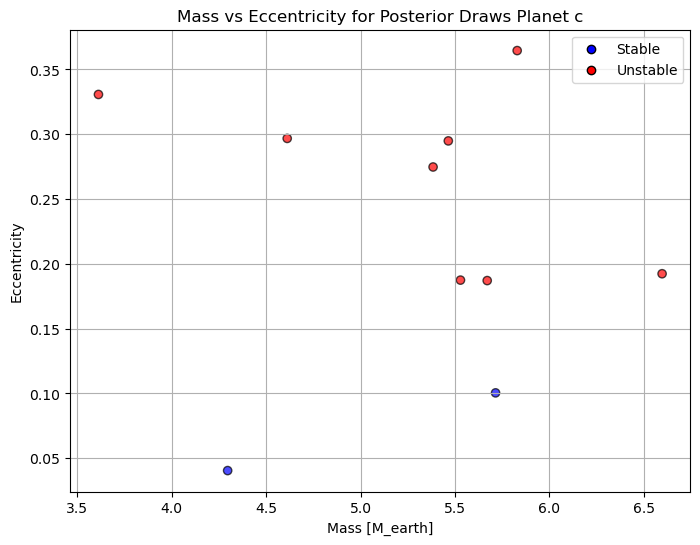

In [56]:
# Store planet mass and eccentricity for each draw
mass_list = []
ecc_list = []
color_list = []
from astropy.constants import M_earth, M_sun
m_c_earth = m_c / (M_earth / M_sun)

for i_idx, draw in enumerate(draw_idx):
    # Example: Planet b
    m_planet = m_c_earth[draw]   # mass
    e_planet = e_c[draw]   # eccentricity
    
    mass_list.append(m_planet)
    ecc_list.append(e_planet)
    
    # Color by stability
    if results[i_idx]:
        color_list.append('blue')   # stable
    else:
        color_list.append('red')    # unstable

# Now plot all draws
plt.figure(figsize=(8,6))
plt.scatter(mass_list, ecc_list, c=color_list, edgecolor='k', alpha=0.7)
# Add dummy points for legend
plt.scatter([], [], c='blue', edgecolor='k', label='Stable')
plt.scatter([], [], c='red', edgecolor='k', label='Unstable')

plt.xlabel("Mass [M_earth]")  # adjust units to match your data
plt.ylabel("Eccentricity")
plt.title("Mass vs Eccentricity for Posterior Draws Planet c")
plt.legend()
plt.grid(True)
plt.show()

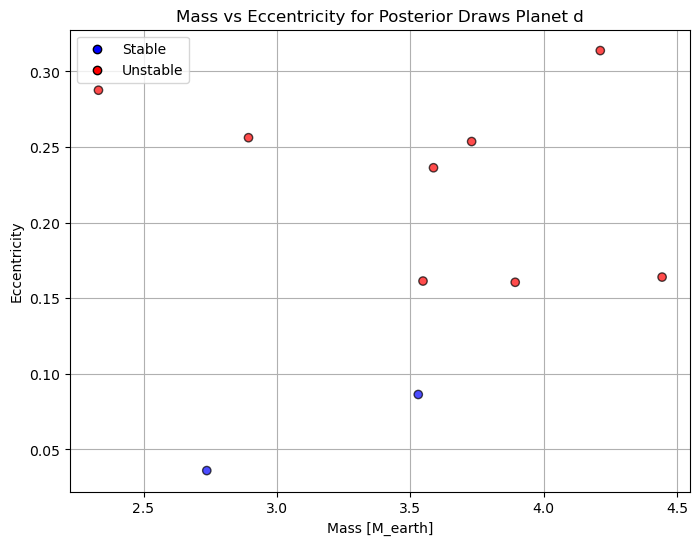

In [57]:
# Store planet mass and eccentricity for each draw
mass_list = []
ecc_list = []
color_list = []

m_d_earth = m_d / (M_earth / M_sun)

for i_idx, draw in enumerate(draw_idx):
    # Example: Planet b
    m_planet = m_d_earth[draw]   # mass
    e_planet = e_d[draw]   # eccentricity
    
    mass_list.append(m_planet)
    ecc_list.append(e_planet)
    
    # Color by stability
    if results[i_idx]:
        color_list.append('blue')   # stable
    else:
        color_list.append('red')    # unstable

# Now plot all draws
plt.figure(figsize=(8,6))
plt.scatter(mass_list, ecc_list, c=color_list, edgecolor='k', alpha=0.7)
# Add dummy points for legend
plt.scatter([], [], c='blue', edgecolor='k', label='Stable')
plt.scatter([], [], c='red', edgecolor='k', label='Unstable')

plt.xlabel("Mass [M_earth]")  # adjust units to match your data
plt.ylabel("Eccentricity")
plt.title("Mass vs Eccentricity for Posterior Draws Planet d")
plt.legend()
plt.grid(True)
plt.show()

# Hamiltonian 

In [10]:
def Lambda_k(mk,ak,mu):
    Lambda_k = mk*np.sqrt(mu*ak)
    return Lambda_k

def Ck(Lambda_k, ek):
    Ck = Lambda_k*(1 - np.sqrt(1-ek**2))
    return Ck

def Gamma_(p,Lambda1, Lambda2):
    Gamma = ((p+1)/p)*Lambda1 + Lambda2
    return Gamma

def G_(Lambda1, Lambda2, C1, C2):
    G = Lambda1 + Lambda2 - C1 - C2
    return G

def theta_res_(p, lambda1, lambda2):
    theta_res = (p+1)*lambda2 - p*lambda1
    return theta_res

def xk(Ck, pomega_k, theta_res):
    xk = np.sqrt(Ck) * np.exp(1j * (pomega_k - theta_res))
    return xk

#--- Laplace coefficient b_s^k(alpha) integral ---
from scipy.integrate import quad
def b(s, k, alpha):
    alpha = float(alpha)
    # Integrand for Laplace coefficient (eq. A10)
    def integrand(phi):
        denom = (1 - 2*alpha*np.cos(phi) + alpha**2)**s
        return np.cos(k*phi) / denom
    integral, _ = quad(integrand, -np.pi, np.pi, limit=200)
    # For k=0 factor 1/2 applies inside the integral by definition
    if k == 0:
        return integral / (2 * np.pi)
    else:
        return integral / np.pi


def script_R1_(alpha, p):
    factor = alpha / 4
    term1 = 3*b(3/2,p,alpha)
    term2 = 2*alpha*b(3/2, p+1, alpha)
    term3 = b(3/2, p+2, alpha)
    script_R1 = -factor*(term1 - term2 - term3)
    # script_R1 = -(alpha/4) * (3*b(3/2,p,alpha) - 2*alpha*b(3/2,p+1,alpha) - b(3/2,p+2,alpha))
    return script_R1

def script_R2_(alpha, p):
    factor = alpha /4
    term1 = 3*b(3/2, p-1, alpha)
    term2 = 2*alpha*b(3/2, p, alpha)
    term3 = b(3/2,p+1,alpha)
    term4 = (1/2)*b(1/2,p,alpha)
    script_R2 = factor*(term1 - term2 - term3) + term4
    # script_R2 = (alpha/4) * (3*b(3/2,p-1,alpha) - 2*alpha*b(3/2,p,alpha) - b(3/2,p+1,alpha)) + (1/2)*b(1/2,p,alpha)
    return script_R2

def R1_(gamma, mu, m2, Lambda1, Lambda2, script_R1):
    term1 = gamma / (1+gamma)
    term2 = (mu**2 * m2**3)/(Lambda2**2)
    term3 = (1/2)*np.sqrt(2/Lambda1)
    R1 = -term1*term2*term3*script_R1
    # R1 = -(gamma/(1+gamma))*((mu**2*m2**3)/(Lambda2**2))*(1/2)*np.sqrt(2/Lambda1)*script_R1
    return R1

def R2_(gamma, mu, m2, Lambda2, script_R2):
    term1 = gamma / (1+gamma)
    term2 = (mu**2 * m2**3) / (Lambda2**2)
    term3 = (1/2)*np.sqrt(2/Lambda2)
    R2 = -term1*term2*term3*script_R2
    # R2 = -(gamma/(1+gamma)) * ((mu**2 * m2**3)/(Lambda2**2)) * (1/2)*np.sqrt(2/Lambda2)*script_R2
    return R2

def I1_(R1, R2, C1, C2, Delta_pomega):
    factor = 1/(R1**2 + R2**2)
    term1 = R1**2 * C1
    term2 = R2**2 * C2
    term3 = 2*R1*R2* np.sqrt(C1*C2)*np.cos(Delta_pomega)
    I1 = factor* (term1 + term2 + term3)
    # I1 = (1/(R1**2 + R2**2))*(R1**2*C1 + R2**2*C2 + 2*R1*R2*np.sqrt(C1*C2)*np.cos(Delta_pomega))
    return I1

def I2_(R1, R2, C1, C2, Delta_pomega):
    factor = 1/(R1**2 + R2**2)
    term1 = R2**2 * C1
    term2 = R1**2 * C2
    term3 = 2*R1*R2* np.sqrt(C1*C2) * np.cos(Delta_pomega)
    I2 = factor*(term1 + term2 - term3)
    # I2 = (1/(R1**2 + R2**2))*(R2**2*C1 + R1**2*C2 - 2*R1*R2*np.sqrt(C1*C2)*np.cos(Delta_pomega))
    return I2

def K2_(P2, Lambda2, p, gamma, alpha):
    n2 = (2*np.pi)/P2
    K2 = -((3*n2)/(2*Lambda2)) * (p+1)**2 * ((gamma+alpha)/alpha)
    return K2

def Delta_G_(Gamma, p, gamma, alpha_0,G):
    Delta_G = (Gamma/(p+1)) * ((p*gamma + (p+1)*alpha_0)/(gamma+alpha_0)) - G
    return Delta_G


def y1_(x1, x2, R1, R2):
    term1 = (R1/(np.sqrt(R1**2 + R2**2))) * x1
    term2 = (R2/(np.sqrt(R1**2 + R2**2))) * x2
    y1 = term1 + term2
    return y1

def y2_(x1, x2, R1, R2):
    term1 = (R2/(np.sqrt(R1**2 + R2**2))) * x1
    term2 = (R1/(np.sqrt(R1**2 + R2**2))) * x2
    y1 = term1 - term2
    return y1

def hamiltonian(K2, I1, I2, Delta_G, eps, R1, R2, theta1):
    H = (K2)*(I1 + I2 - Delta_G)**2 + 2*eps*np.sqrt(R1**2 + R2**2)*np.sqrt(I1)*np.cos(theta1)
    return H


## defining Y1 and Y2

In [11]:
# def Y1_(e_tilda_1, e_tilda_2, pomega_1, pomega_2, gamma, theta_res):
#     numerator = (e_tilda_1*np.exp(1j * pomega_1)) - (1.22*e_tilda_2*np.exp(1j * pomega_2))
#     denominator = np.sqrt(1 + 1.31*gamma)
#     Y1 = (numerator/denominator) * np.exp(-1j * theta_res)
#     return Y1

# def Y2_(e_tilda_1, e_tilda_2, pomega_1, pomega_2, gamma, theta_res):
#     numerator = (1.07*gamma*e_tilda_1*np.exp(1j * pomega_1)) + (e_tilda_2*np.exp(1j * pomega_2))
#     denominator = np.sqrt(1 + 1.31*gamma)
#     Y2 = (numerator/denominator) * np.exp(-1j * theta_res)
#     return Y2

def Y1_(Lambda_c, y1):
    term1 = np.sqrt(2/Lambda_c)
    Y1 = term1 * y1
    return Y1


def Y2_(Lambda_d, y2):
    term1 = np.sqrt(2/Lambda_d)
    Y2 = term1 * y2
    return Y2

## make posterior distribution plot for Y1

In [12]:
### conversions
solar_mass_2_kg = 1.989e30 # [kg per solar mass]
d_2_s = 86400 # [seconds per day]

### system constants 
m_star = 0.81  # [solar mass]

from astropy import units as u
from astropy import constants as c
G_const_si = c.G
G_const = c.G.to(u.AU**3 / u.M_sun / u.day**2).value


### posterior samples 
ecosw_c = samples["ecosw"][:, 0]
esinw_c = samples["esinw"][:, 0]
e_c = samples["ecc"][:,0]
P_c = samples["period"][:,0] # [days]
Tc_c = samples["tic"][:,0] # [days]
m_c = samples["pmass"][:,0] # [solar mass]

ecosw_d = samples["ecosw"][:, 1]
esinw_d = samples["esinw"][:, 1]
e_d = samples["ecc"][:,1]
P_d = samples["period"][:,1] # [days]
Tc_d = samples["tic"][:,1] # [days]
m_d = samples["pmass"][:,1] # [solar mass]  

### calculated params
a_c = np.array(((G_const*m_star*P_c**2)/(4*np.pi**2))**(1.0/3)) # [AU]
a_d = np.array(((G_const*m_star*P_d**2)/(4*np.pi**2))**(1/3)) # [AU]


omega_c = np.arctan2(esinw_c, ecosw_c) # [rad]
omega_d = np.arctan2(esinw_d, ecosw_d) # [rad]

# times = np.array([1980.] * len(omega_b))
times = Tc_d

Mean_anomaly_c = mean_anomaly(times, omega_c, e_c, Tc_c, P_c)
Mean_anomaly_d = mean_anomaly(times, omega_d, e_d, Tc_d, P_d)
e_tilda_c = np.sqrt(2*(1 - np.sqrt(1 - e_c**2)))
e_tilda_d = np.sqrt(2*(1 - np.sqrt(1 - e_d**2)))

### keep Omega constant
value_Omega_c = 0  # [deg]
Omega_c = [np.radians(value_Omega_c)] * len(omega_c)  # [rad]
value_Omega_d = 0 # [deg]
Omega_d = [np.radians(value_Omega_d)] * len(omega_d)  # [rad]

pomega_c = omega_c + Omega_c
pomega_d = omega_d + Omega_d
lambda_c = omega_c + Omega_c + Mean_anomaly_c
lambda_d = omega_d + Omega_d + Mean_anomaly_d
p = np.array([3] * len(lambda_c))
theta_res = theta_res_(p, lambda_c, lambda_d)

# print(a_b)
# print(a_c)
print(e_tilda_c)
print(e_tilda_d)
print(e_c)
print(e_d)
print(pomega_c)
print(pomega_d)
print(theta_res)

[0.37665936 0.21652122 0.26969463 ... 0.05814444 0.06599297 0.31432894]
[0.32307786 0.18492489 0.23178424 ... 0.05088912 0.05752919 0.27035663]
[0.36991948 0.21524875 0.26723137 ... 0.0581205  0.06595662 0.31042257]
[0.31883457 0.18413252 0.23022243 ... 0.05087234 0.05750603 0.26787508]
[-2.24668002 -2.44829369 -2.42224765 ...  1.93185019 -2.51833057
 -2.49720693]
[-2.2481184  -2.44839859 -2.42526627 ...  1.95874572 -2.53700137
 -2.4995904 ]
[ 9.075359  9.015396  9.057185 ... 15.191414  8.93432   9.102854]


In [13]:
eps = (m_c+m_d)/m_star
mu = np.array([G_const*m_star] * len(omega_c))
gamma = m_c/m_d 
alpha = a_c/a_d 
alpha_0 = (p/(p+1))**(2/3)
Delta_pomega = pomega_d - pomega_c # ??

print(alpha)
print(alpha_0)
print(Delta_pomega)

[0.82199425 0.8219926  0.82199776 ... 0.8220105  0.82199997 0.821998  ]
[0.82548181 0.82548181 0.82548181 ... 0.82548181 0.82548181 0.82548181]
[-0.00143838 -0.0001049  -0.00301862 ...  0.02689552 -0.0186708
 -0.00238347]


In [14]:


theta_res = theta_res_(p, lambda_c, lambda_d)

Lambda_c = Lambda_k(m_c,a_c,mu)
Lambda_d = Lambda_k(m_d,a_d,mu)

C_c = Ck(Lambda_c, e_c)
C_d = Ck(Lambda_d, e_d)

x1 = xk(C_c, pomega_c, theta_res)
x2 = xk(C_d, pomega_d, theta_res)

script_R1 = np.array([script_R1_(a, p_val) for a, p_val in zip(alpha, p)])
script_R2 = np.array([script_R2_(a, p_val) for a, p_val in zip(alpha, p)])
# script_R1 = script_R1_(alpha, p)
# script_R2 = script_R2_(alpha, p)

R1 = R1_(gamma, mu, m_d, Lambda_c, Lambda_d, script_R1)
R2 = R2_(gamma, mu, m_d, Lambda_d, script_R2)



y1 = y1_(x1, x2, R1, R2)
y2 = y2_(x1, x2, R1, R2)

## Plotting posterior for Y1

In [15]:
# Y1 = Y1_(e_tilda_c, e_tilda_d, pomega_c, pomega_d, gamma, theta_res)

Y1 = Y1_(Lambda_c, y1)

print(np.median(Y1))

(3.8824102e-05+0.000849514j)


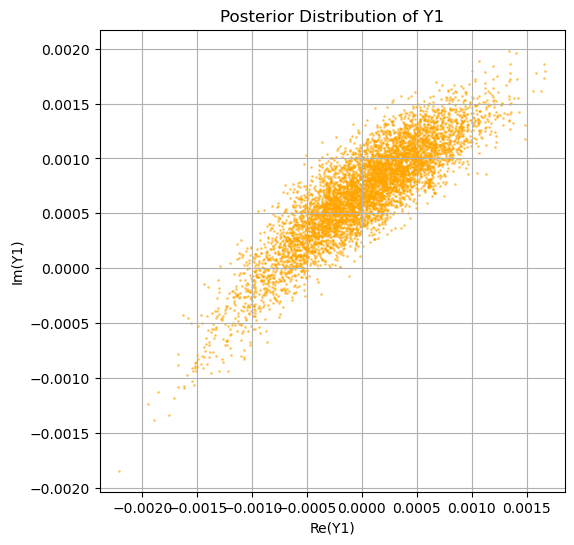

In [16]:
# Extract real and imaginary parts
Y1_real = np.real(Y1)
Y1_imag = np.imag(Y1)

plt.figure(figsize=(6, 6))
plt.scatter(Y1_real, Y1_imag, s=1, alpha=0.5,color='orange')  # Adjust s for point size, alpha for transparency
plt.xlabel("Re(Y1)")
plt.ylabel("Im(Y1)")
plt.title("Posterior Distribution of Y1")
plt.grid(True)
plt.axis('equal')  # Optional: ensures square aspect ratio
plt.show()

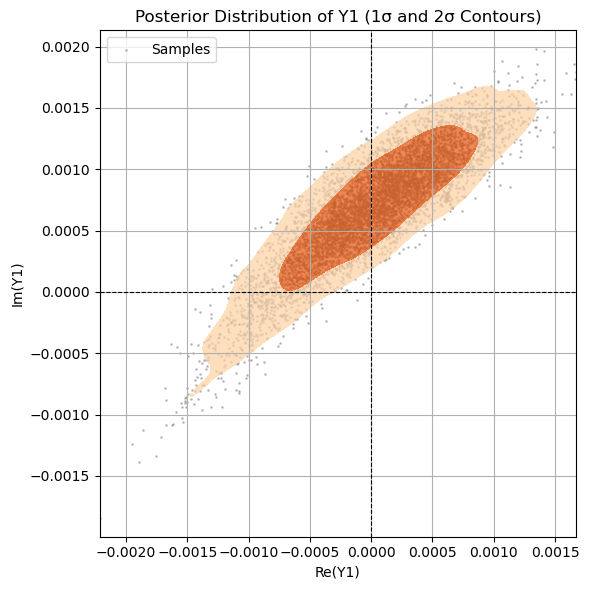

In [17]:
from scipy.stats import gaussian_kde
import matplotlib.pyplot as plt
import numpy as np

def compute_kde_contour_levels(x, y, gridsize=100):
    data = np.vstack([x, y])
    kde = gaussian_kde(data)
    x_min, x_max = x.min(), x.max()
    y_min, y_max = y.min(), y.max()
    X, Y = np.mgrid[x_min:x_max:gridsize*1j, y_min:y_max:gridsize*1j]
    positions = np.vstack([X.ravel(), Y.ravel()])
    Z = np.reshape(kde(positions).T, X.shape)
    return X, Y, Z

def get_sigma_contour_levels(Z):
    Z_flat = Z.flatten()
    Z_sorted = np.sort(Z_flat)[::-1]
    cumsum = np.cumsum(Z_sorted)
    cumsum /= cumsum[-1]  # Normalize to total probability 1
    levels = []
    for sigma in [0.683, 0.954]:
        idx = np.searchsorted(cumsum, sigma)
        levels.append(Z_sorted[idx])
    return sorted(levels)

# Extract real and imaginary parts of Y1
Y1_real = np.real(Y1)
Y1_imag = np.imag(Y1)

# Compute KDE and contour levels
X_1, Y_1, Z_1 = compute_kde_contour_levels(Y1_real, Y1_imag)
levels_1 = get_sigma_contour_levels(Z_1)

# Plot
fig, ax = plt.subplots(figsize=(6, 6))
plt.scatter(Y1_real, Y1_imag, s=1, alpha=0.4, color='grey',label='Samples')

contour = ax.contourf(X_1, Y_1, Z_1, levels=levels_1 + [Z_1.max()], colors=["#fdd0a2", "#e6550d"], alpha=0.7)

# Add dashed lines at x=0 and y=0
ax.axhline(0, color='black', linestyle='--', lw=0.8)
ax.axvline(0, color='black', linestyle='--', lw=0.8)

# Plot formatting
ax.set_xlabel("Re(Y1)")
ax.set_ylabel("Im(Y1)")
ax.set_title("Posterior Distribution of Y1 (1σ and 2σ Contours)")
ax.grid(True)
ax.axis('equal')
plt.legend()
plt.tight_layout()
plt.show()


## Posterior for Y2

In [18]:
# Y2 = Y2_(e_tilda_c, e_tilda_d, pomega_c, pomega_d, gamma, theta_res)
Y2 = Y2_(Lambda_d, y2)
print(Y2)

[-0.18208402-0.53695893j -0.1430989 -0.2830041j  -0.1823182 -0.34603295j
 ... -0.06997306+0.05713653j -0.04575863-0.09168541j
 -0.2552158 -0.36879596j]


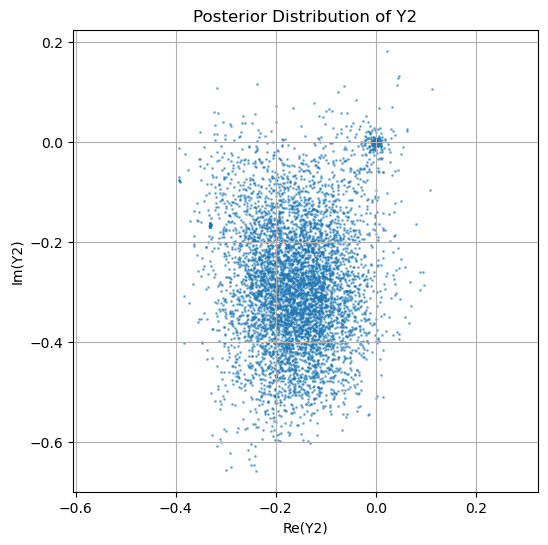

In [19]:
# Extract real and imaginary parts
Y2_real = np.real(Y2)
Y2_imag = np.imag(Y2)

plt.figure(figsize=(6, 6))
plt.scatter(Y2_real, Y2_imag, s=1, alpha=0.5)  # Adjust s for point size, alpha for transparency
plt.xlabel("Re(Y2)")
plt.ylabel("Im(Y2)")
plt.title("Posterior Distribution of Y2")
plt.grid(True)
plt.axis('equal')  # Optional: ensures square aspect ratio
plt.show()

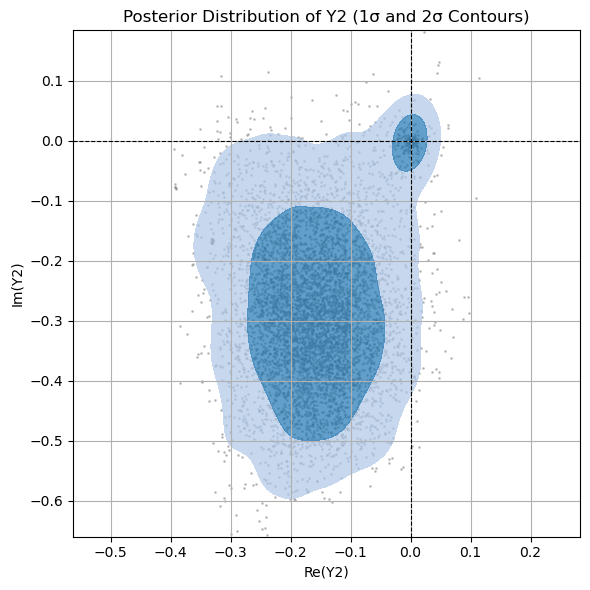

In [20]:
# Extract real and imaginary parts of Y1
Y2_real = np.real(Y2)
Y2_imag = np.imag(Y2)

# Compute KDE and contour levels
X_2, Y_2, Z_2 = compute_kde_contour_levels(Y2_real, Y2_imag)
levels_2 = get_sigma_contour_levels(Z_2)

# Plot
fig, ax = plt.subplots(figsize=(6, 6))
plt.scatter(Y2_real, Y2_imag, s=1, alpha=0.4, color='grey',label='Samples')

contour = ax.contourf(X_2, Y_2, Z_2, levels=levels_2 + [Z_2.max()], colors=["#aec7e8", "#1f77b4"], alpha=0.7)

# Add dashed lines at x=0 and y=0
ax.axhline(0, color='black', linestyle='--', lw=0.8)
ax.axvline(0, color='black', linestyle='--', lw=0.8)

# Plot formatting
ax.set_xlabel("Re(Y2)")
ax.set_ylabel("Im(Y2)")
ax.set_title("Posterior Distribution of Y2 (1σ and 2σ Contours)")
ax.grid(True)
ax.axis('equal')

plt.tight_layout()
plt.show()

/var/folders/69/wlx91x8s1x34mphlfjy0h4pm0000gn/T/ipykernel_10891/123873622.py:24: UserWarning: Setting the 'color' property will override the edgecolor or facecolor properties.
  ax.annotate('$Y_1$', xy=(0.0003, 0.000055), xytext=(0.1, 0.0055 + 0.1), arrowprops=dict(facecolor='#e6550d', arrowstyle='->',color='#e6550d'), color='#e6550d', fontsize=18)
/var/folders/69/wlx91x8s1x34mphlfjy0h4pm0000gn/T/ipykernel_10891/123873622.py:25: UserWarning: Setting the 'color' property will override the edgecolor or facecolor properties.
  ax.annotate('$Y_2$', xy=(-0.1, 0.0), xytext=(-0.25, 0.05 + 0.1), arrowprops=dict(facecolor='#2171b5', arrowstyle='->',color='#2171b5'),color='#2171b5', fontsize=18)


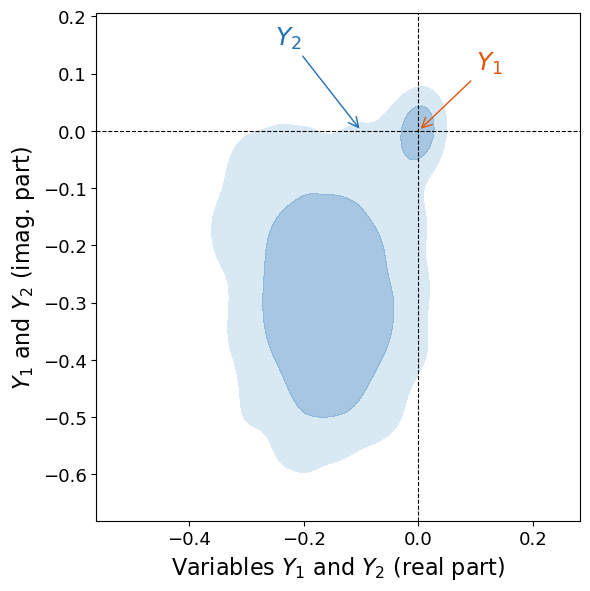

In [21]:
# Plot Y1 and Y2 together
fig, ax = plt.subplots(figsize=(6, 6))
contour = ax.contourf(X_2, Y_2, Z_2, 
                      levels=levels_2 + [Z_2.max()], 
                      colors=['#9ecae1', '#2171b5'], 
                      alpha=0.4)
contour = ax.contourf(X_1, Y_1, Z_1, 
                      levels=levels_1 + [Z_1.max()], 
                      colors=["#fdd0a2", "#e6550d"], 
                      alpha=0.7)

# Plot formatting
ax.set_xlabel("Variables $Y_1$ and $Y_2$ (real part)", fontsize=16)
ax.set_ylabel("$Y_1$ and $Y_2$ (imag. part)", fontsize=16)
# ax.set_title("Posterior Distribution of Y1 and Y2 (1σ and 2σ Contours)")
# ax.grid(True)
ax.axis('equal')

# Add dashed lines at x=0 and y=0
ax.axhline(0, color='black', linestyle='--', lw=0.8)
ax.axvline(0, color='black', linestyle='--', lw=0.8)

# Annotations and arrows
ax.annotate('$Y_1$', xy=(0.0003, 0.000055), xytext=(0.1, 0.0055 + 0.1), arrowprops=dict(facecolor='#e6550d', arrowstyle='->',color='#e6550d'), color='#e6550d', fontsize=18)
ax.annotate('$Y_2$', xy=(-0.1, 0.0), xytext=(-0.25, 0.05 + 0.1), arrowprops=dict(facecolor='#2171b5', arrowstyle='->',color='#2171b5'),color='#2171b5', fontsize=18)
plt.tick_params(axis='both', labelsize=13) 
plt.tight_layout()
plt.show()

## computing Hamiltonian

In [22]:
### calculated params 
eps = (m_c+m_d)/m_star
mu = np.array([G_const*m_star] * len(omega_c)) # as defined in paper, is this different from mu from posteriors?
gamma = m_c/m_d 
alpha = a_c/a_d 
alpha_0 = (p/(p+1))**(2/3)
Delta_pomega = pomega_c - pomega_d # ??

### use definitions to define other variables for hamiltonian
Lambda_c = Lambda_k(m_c, a_c, mu)
Lambda_d = Lambda_k(m_d, a_d, mu)

C_c = Ck(Lambda_c, e_c)
C_d = Ck(Lambda_d, e_d)

Gamma = Gamma_(p, Lambda_c,Lambda_d)
G = G_(Lambda_c, Lambda_d, C_c, C_d)

theta_res = theta_res_(p, lambda_c, lambda_d)

x_c = xk(C_c, pomega_c, theta_res)
x_d = xk(C_d, pomega_d, theta_res)

e_tilda_c = np.sqrt(2*(1 - np.sqrt(1 - e_c**2)))
e_tilda_d = np.sqrt(2*(1 - np.sqrt(1 - e_d**2)))

script_R1 = np.array([script_R1_(a, p_val) for a, p_val in zip(alpha_0, p)])
script_R2 = np.array([script_R2_(a, p_val) for a, p_val in zip(alpha_0, p)])

R1 = R1_(gamma, mu, m_d, Lambda_c, Lambda_d, script_R1)
R2 = R2_(gamma, mu, m_d, Lambda_d, script_R2)

I1 = I1_(R1, R2, C_c, C_d, Delta_pomega)
I2 = I2_(R1, R2, C_c, C_d, Delta_pomega)

K2 = K2_(P_d, Lambda_d, p, gamma, alpha_0)

Delta_G = Delta_G_(Gamma, p, gamma, alpha_0, G)

y1 = y1_(x_c,x_d,R1,R2)
theta1 = np.angle(y1)
print(f'Y1 before: {Y1}')
# Y1 = np.sqrt(2/Lambda_c) * y1
print(f'Y1: {Y1}')

print(f'alpha: {alpha}')
print(f'alpha_0: {alpha_0}')
print(f"eps: {eps}")

print(f"Lambda_c: {Lambda_c}")
print(f"Lambda_d: {Lambda_d}")
print(f"gamma: {gamma}")
print(f"mu: {mu}")
print(f"m_d: {m_d}")
print(f"script_R1: {script_R1}")
print(f"script_R2: {script_R2}")

print(f"K2 = {K2}")
print(f"I1 = {I1}")
print(f"I2 = {I2}")
print(f"Delta_G = {Delta_G}")
print(f"eps = {eps}")
print(f"R1 = {R1}")
print(f"R2 = {R2}")
print(f"theta1: {theta1}")

Y1 before: [ 1.1389180e-05+9.9471200e-04j  4.8403570e-04+9.8662451e-04j
 -2.4469779e-04+5.7048223e-04j ... -9.5191406e-04-3.5989363e-04j
 -8.1233954e-04-7.8647587e-05j -1.9250769e-04+5.1537412e-04j]
Y1: [ 1.1389180e-05+9.9471200e-04j  4.8403570e-04+9.8662451e-04j
 -2.4469779e-04+5.7048223e-04j ... -9.5191406e-04-3.5989363e-04j
 -8.1233954e-04-7.8647587e-05j -1.9250769e-04+5.1537412e-04j]
alpha: [0.82199425 0.8219926  0.82199776 ... 0.8220105  0.82199997 0.821998  ]
alpha_0: [0.82548181 0.82548181 0.82548181 ... 0.82548181 0.82548181 0.82548181]
eps: [3.3853754e-05 3.7817041e-05 3.0084801e-05 ... 2.3659817e-05 2.4480047e-05
 2.9971208e-05]
Lambda_c: [1.1009028e-07 1.1938671e-07 9.3606467e-08 ... 7.9047716e-08 8.1839566e-08
 9.1324502e-08]
Lambda_d: [7.1942118e-08 8.4326615e-08 6.8595668e-08 ... 4.7954643e-08 4.9560487e-08
 7.0463713e-08]
gamma: [1.6878405 1.5615553 1.5051292 ... 1.8181092 1.8213434 1.4295074]
mu: [0.00023969 0.00023969 0.00023969 ... 0.00023969 0.00023969 0.00023969]
m_

In [23]:
print(f'Median Y1: {np.median(Y1)}')
print(f'Median Re(Y1): {np.real(np.median(Y1))}')
print(f'Median Im(Y1): {np.imag(np.median(Y1))}')
Y1_median = np.median(Y1)
Re_Y1_median = np.real(np.median(Y1))
Im_Y1_median = np.imag(np.median(Y1))
print(Y1)
print(Y1_median)
dist=np.abs(Y1-Y1_median)
print(dist)
median_idx = np.argmin(dist)
print(median_idx)
median_idx = 4815 # known stable posterior sample (low ecc)
print(median_idx)

Median Y1: (3.8824102375656366e-05+0.0008495139773003757j)
Median Re(Y1): 3.8824102375656366e-05
Median Im(Y1): 0.0008495139773003757
[ 1.1389180e-05+9.9471200e-04j  4.8403570e-04+9.8662451e-04j
 -2.4469779e-04+5.7048223e-04j ... -9.5191406e-04-3.5989363e-04j
 -8.1233954e-04-7.8647587e-05j -1.9250769e-04+5.1537412e-04j]
(3.8824102e-05+0.000849514j)
[0.00014777 0.00046585 0.0003978  ... 0.0015634  0.00125935 0.0004064 ]
4693
4815


In [24]:
I1_val = I1[median_idx]
I2_val = I2[median_idx]
R1_val = R1[median_idx]
R2_val = R2[median_idx]
K2_val = K2[median_idx]
Delta_G_val = Delta_G[median_idx]
eps_val = eps[median_idx]

H_grid min: -1.4482956e-13
H_grid max: -9.203215e-14


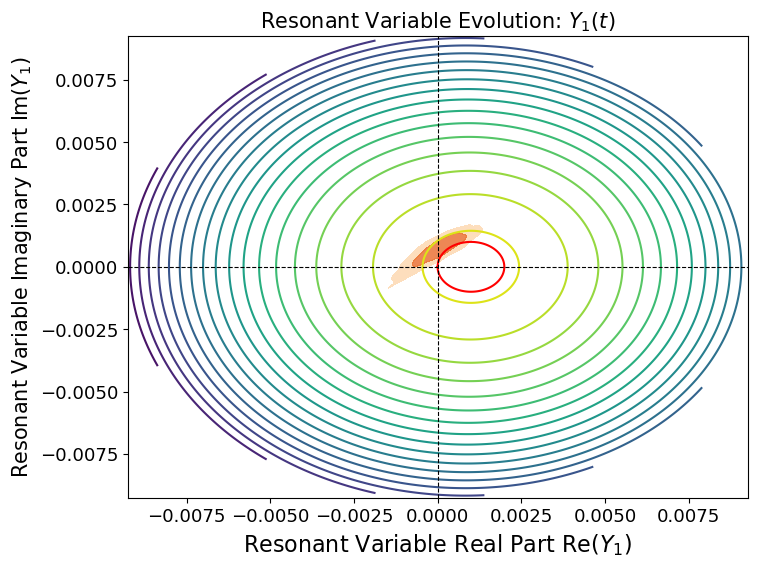

In [25]:
# Define grid for I1 and theta1
# I1_vals = np.linspace(I1_val*0.08, I1_val*4, 8000)   # I1 must be >= 0, avoid 0 to prevent sqrt(0)
I1_vals = np.linspace(I1.min()*0.002, I1.max()*6, 8000)   # I1 must be >= 0, avoid 0 to prevent sqrt(0)

# I1_vals = np.linspace(0.000000001, 0.02, 8000)
theta1_vals = np.linspace(0, 2*np.pi, 8000)

I1_grid, theta1_grid = np.meshgrid(I1_vals, theta1_vals)


# Compute Hamiltonian on the grid
H_grid = hamiltonian(K2_val, I1_grid, I2_val, Delta_G_val, eps_val, R1_val, R2_val, theta1_grid)
print("H_grid min:", H_grid.min())
print("H_grid max:", H_grid.max())


y_1 = np.sqrt(I1_grid)*np.exp(1j*theta1_grid)
Y_1_ = np.sqrt(2/np.median(Lambda_c)) * y_1
Re_Y1 = np.real(Y_1_)
Im_Y1 = np.imag(Y_1_)

# Plot Hamiltonian contours in (Re_y1, Im_y1) space
fig, ax = plt.subplots(figsize=(8, 6))

levels_circulating=[-0.08*10**(-10), -0.04*10**(-10)]
levels_resonant = [-0.01*10**(-10), 0.0, 0.01*10**(-10)]

# contours_circ = ax.contour(Re_Y1, Im_Y1, H_grid, levels=levels_circulating, colors='black',linestyles='-')
# contours_res = ax.contour(Re_Y1, Im_Y1, H_grid, levels=levels_resonant, colors='green',linestyles='-')

contours = ax.contour(Re_Y1, Im_Y1, H_grid, levels=20, cmap="viridis")

# 1. Find index closest to theta1 = π
theta1_index = np.argmin(np.abs(theta1_vals - np.pi))

# 2. Slice the Hamiltonian at that angle
H_slice = H_grid[theta1_index, :]

# 3. Find max of that slice (typical for saddle point location)
I1_saddle_index = np.argmax(H_slice)
H_saddle = H_slice[I1_saddle_index]

# Plot separatrix: contour at saddle energy
contour_sep = ax.contour(Re_Y1, Im_Y1, H_grid, levels=[H_saddle], colors='red',linestyles='-')#, linewidths=2.0)

# plt.scatter(Re_Y1_vals, Im_Y1_vals, c='blue', s=1, label=r'$Y_1(t)$ trajectory')

### add Y1 posterior distribution
contour = ax.contourf(X_1, Y_1, Z_1, 
                      levels=levels_1 + [Z_1.max()], 
                      colors=["#fdd0a2", "#e6550d"], 
                      alpha=0.7)
# Text annotation
# ax.text(0.025, 0.01, 'Posterior\ndistribution', color='#e6550d', fontsize=13, ha='center')

# plot median Y1 
# plt.scatter(np.real(np.median(Y1)), np.imag(np.median(Y1)), color='purple',label='median Y1')

# Add dashed lines at x=0 and y=0
ax.axhline(0, color='black', linestyle='--', lw=0.8)
ax.axvline(0, color='black', linestyle='--', lw=0.8)


ax.set_xlabel(r'Resonant Variable Real Part Re$(Y_1)$', fontsize=16)
ax.set_ylabel(r'Resonant Variable Imaginary Part Im$(Y_1)$', fontsize=15)
ax.set_title(r'Resonant Variable Evolution: $Y_1(t)$', fontsize=15)
# ax.grid(True)
plt.tick_params(axis='both', labelsize=13)
# plt.xlim(-0.055,0.055)
# plt.ylim(-0.045, 0.045)
# plt.legend()
plt.show()

# Check rebound

In [26]:
### initialize simulation at values near the median Y1 values
m_c_val = m_c[median_idx]
m_d_val = m_d[median_idx]
a_c_val = a_c[median_idx]
a_d_val = a_d[median_idx]
e_c_val = e_c[median_idx]
e_d_val = e_d[median_idx]
lambda_c_val = lambda_c[median_idx]
lambda_d_val = lambda_d[median_idx]
pomega_c_val = pomega_c[median_idx]
pomega_d_val = pomega_d[median_idx]
P_c_val = P_c[median_idx]

In [42]:
### time settings 
# t_max = 1e4 * P_c_val
t_max = 1e4 * P_c_val

Nout = 20000
times = np.linspace(0,t_max,Nout)


In [43]:
sim = rebound.Simulation()
sim.add(m=m_star)

### initialize with median values from posteriors?
sim.add(m=mass_b, a=a_b, e=e_b, l=lambda_b, pomega=pomega_b)
sim.add(m=m_c_val, a=a_c_val, e=e_c_val, l=lambda_c_val, pomega=pomega_c_val)
sim.add(m=m_d_val, a=a_d_val, e=e_d_val, l=lambda_d_val, pomega=pomega_d_val)
sim.add(m=mass_e, a=a_e, e=e_e, l=lambda_e, pomega=pomega_e)

sim.move_to_com()

In [44]:
def compute_resonant_vars(sim):
    p = 3  # for 4:3 resonance
    star = sim.particles[0]
    p0 = sim.particles[1]
    p1 = sim.particles[2]
    p2 = sim.particles[3]
    p3 = sim.particles[4]
    mu = G_const*m_star

    # Get osculating orbital elements relative to star
    o1 = p1.orbit()
    o2 = p2.orbit()

    alpha_ = o1.a / o2.a
    gamma_ = p1.m / p2.m
    eps_ = (p1.m + p2.m) / m_star
    Delta_pomega_ = o2.pomega - o1.pomega
    P_d = 2*np.pi*np.sqrt(o2.a**3/(G_const*m_star))

    Lambda_c = Lambda_k(p1.m, o1.a, mu)
    Lambda_d = Lambda_k(p2.m, o2.a, mu)
    
    C_c = Ck(Lambda_c, o1.e)
    C_d = Ck(Lambda_d, o2.e)

    Gamma = Gamma_(p, Lambda_c,Lambda_d)
    G = G_(Lambda_c, Lambda_d, C_c, C_d)

    theta_res = theta_res_(p, o1.l, o2.l)

    x_c = xk(C_c, o1.pomega, theta_res)
    x_d = xk(C_d, o2.pomega, theta_res)
    
    script_R1 = script_R1_(alpha_, p)
    script_R2 = script_R2_(alpha_, p)
    
    R1 = R1_(gamma_, mu, p2.m, Lambda_c, Lambda_d, script_R1)
    R2 = R2_(gamma_, mu, p2.m, Lambda_d, script_R2)

    K2 = K2_(P_d, Lambda_d, p, gamma_, alpha_)
    Delta_G = Delta_G_(Gamma, p, gamma_, alpha_, G)
    
    I1 = I1_(R1, R2, C_c, C_d, Delta_pomega_)
    I2 = I2_(R1, R2, C_c, C_d, Delta_pomega_)

    y1 = y1_(x_c,x_d,R1,R2)
    y2 = y2_(x_c, x_d, R1, R2)
    theta1 = np.angle(y1)

    e_tilda_c = np.sqrt(2*(1 - np.sqrt(1 - o1.e**2)))
    e_tilda_d = np.sqrt(2*(1 - np.sqrt(1 - o2.e**2)))

    Y1 = Y1_(Lambda_c, y1)
    Y2 = Y2_(Lambda_d, y2)
    # Y1 = Y1_(e_tilda_c, e_tilda_d, o1.pomega, o2.pomega, gamma_, theta_res)
    # Y2 = Y2_(e_tilda_c, e_tilda_d, o1.pomega, o2.pomega, gamma_, theta_res)

    H = hamiltonian(K2, I1, I2, Delta_G, eps_, R1, R2, theta1)

    ### tracking eccentricities
    eb_ = o1.e
    ec_ = o2.e

    phi_1 = theta_res - o1.pomega
    phi_2 = theta_res - o2.pomega

    return H, Y1, Y2, I1, I2, theta1, eb_, ec_, Delta_pomega_, phi_1, phi_2


In [45]:
sim.integrate(0)
Hi, Y1i, Y2i, I1i, I2i, theta1i, ebi, eci, Delta_pomegai, phi_1i, phi_2i = compute_resonant_vars(sim)
print('initial values:')
print(f'Hi {Hi}')
print(f'Y1i: {Y1i}')
# print(f'intial Y1: {Y1[0]}')
print(f'Y2i: {Y2i}')
print(f'I1i: {I1i}')
print(f'I2i: {I2i}')
print(f'theta1i: {theta1i}')

initial values:
Hi -8.374743019283822e-13
Y1i: (-0.0006038399054948796+0.00038475803725684303j)
Y2i: (-0.0025659068815126747+0.027655690747710585j)
I1i: 2.4000839528786663e-14
I2i: 2.2595337977154123e-11
theta1i: 2.574278674211515


In [46]:
H_vals = np.zeros(len(times))
Re_Y1_vals = np.zeros(len(times))
Im_Y1_vals = np.zeros(len(times))
Re_Y2_vals = np.zeros(len(times))
Im_Y2_vals = np.zeros(len(times))
I1_vals = np.zeros(len(times))
I2_vals = np.zeros(len(times))
theta1_vals = np.zeros(len(times))
eb_vals = np.zeros(len(times))
ec_vals = np.zeros(len(times))
Delta_pomega_vals = np.zeros(len(times))
phi1_vals = np.zeros(len(times))
phi2_vals = np.zeros(len(times))


for i, t in enumerate(times):
    sim.integrate(t)
    H_t, Y1_t, Y2_t, I1_t, I2_t, theta1_t, eb_t, ec_t, Delta_pomega_t, phi1_t, phi2_t = compute_resonant_vars(sim)
    # print(Y1)
    H_vals[i] = H_t
    Re_Y1_vals[i] = np.real(Y1_t)
    Im_Y1_vals[i] = np.imag(Y1_t)
    Re_Y2_vals[i] = np.real(Y2_t)
    Im_Y2_vals[i] = np.imag(Y2_t)
    I1_vals[i] = I1_t
    I2_vals[i] = I2_t
    theta1_vals[i] = theta1_t
    eb_vals[i] = eb_t
    ec_vals[i] = ec_t
    Delta_pomega_vals[i] = Delta_pomega_t
    phi1_vals[i] = phi1_t
    phi2_vals[i] = phi2_t


In [47]:
print(len(times))
print(len(H_vals))

20000
20000


In [50]:
# save data to load in faster
# Create a DataFrame
df = pd.DataFrame({
    'times': times,
    'H': H_vals,
    'Re_Y1': Re_Y1_vals,
    'Im_Y1': Im_Y1_vals,
    'Re_Y2': Re_Y2_vals,
    'Im_Y2': Im_Y2_vals,
    'I1': I1_vals,
    'I2': I2_vals,
    'theta1': theta1_vals,
    'eb': eb_vals,
    'ec': ec_vals,
    'Delta_pomega': Delta_pomega_vals,
    'phi1': phi1_vals,
    'phi2': phi2_vals,
    
})

# Save to CSV
df.to_csv('trajectory_rebound.csv', index=False)




In [33]:
# # load in csv
# # Read the CSV
# df = pd.read_csv('trajectory_rebound.csv')

# # Access the columns as needed
# H_vals = df['H'].to_numpy()
# Re_Y1_vals = df['Re_Y1'].to_numpy()
# Im_Y1_vals = df['Im_Y1'].to_numpy()
# Re_Y2_vals = df['Re_Y2'].to_numpy()
# Im_Y2_vals = df['Im_Y2'].to_numpy()
# I1_vals = df['I1'].to_numpy()
# I2_vals = df['I2'].to_numpy()
# theta1_vals = df['theta1'].to_numpy()
# eb_vals = df['eb'].to_numpy()
# ec_vals = df['ec'].to_numpy()
# Delta_pomega_vals = df['Delta_pomega'].to_numpy()
# phi1_vals = df['phi1'].to_numpy()
# phi2_vals = df['phi2'].to_numpy()

H_grid min: -1.4482956e-13
H_grid max: -9.2032135e-14


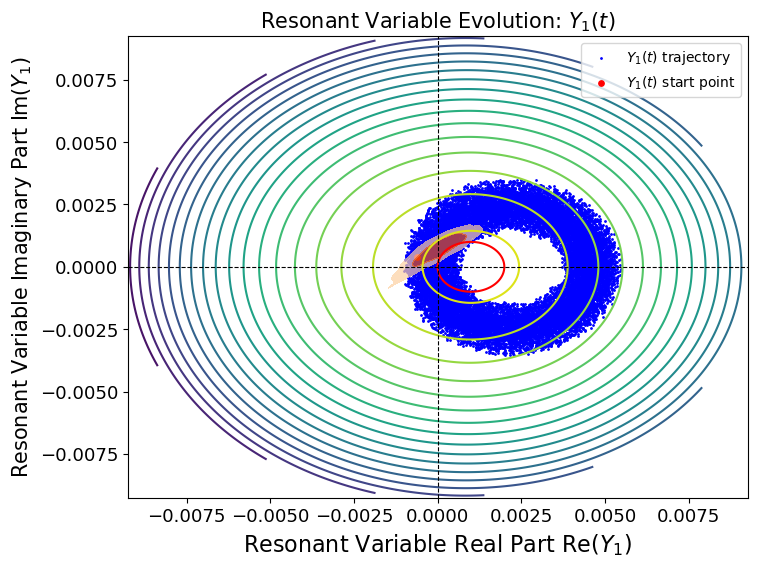

In [34]:
# Define grid for I1 and theta1
# I1_vals = np.linspace(I1_val*0.08, I1_val*4, 8000)   # I1 must be >= 0, avoid 0 to prevent sqrt(0)
I1_vals = np.linspace(I1.min()*0.002, I1.max()*6, 10000)   # I1 must be >= 0, avoid 0 to prevent sqrt(0)

# I1_vals = np.linspace(0.000000001, 0.02, 8000)
theta1_vals = np.linspace(0, 2*np.pi, 10000)

I1_grid, theta1_grid = np.meshgrid(I1_vals, theta1_vals)


# Compute Hamiltonian on the grid
H_grid = hamiltonian(K2_val, I1_grid, I2_val, Delta_G_val, eps_val, R1_val, R2_val, theta1_grid)
print("H_grid min:", H_grid.min())
print("H_grid max:", H_grid.max())

y_1 = np.sqrt(I1_grid)*np.exp(1j*theta1_grid)
Y_1_ = np.sqrt(2/np.median(Lambda_c)) * y_1
Re_Y1 = np.real(Y_1_)
Im_Y1 = np.imag(Y_1_)

# Plot Hamiltonian contours in (Re_y1, Im_y1) space
fig, ax = plt.subplots(figsize=(8, 6))

levels_circulating=[-0.08*10**(-10), -0.04*10**(-10)]
levels_resonant = [-0.01*10**(-10), 0.0, 0.01*10**(-10)]

# contours_circ = ax.contour(Re_Y1, Im_Y1, H_grid, levels=levels_circulating, colors='black',linestyles='-')
# contours_res = ax.contour(Re_Y1, Im_Y1, H_grid, levels=levels_resonant, colors='green',linestyles='-')

contours = ax.contour(Re_Y1, Im_Y1, H_grid, levels=20, cmap="viridis")

# 1. Find index closest to theta1 = π
theta1_index = np.argmin(np.abs(theta1_vals - np.pi))

# 2. Slice the Hamiltonian at that angle
H_slice = H_grid[theta1_index, :]

# 3. Find max of that slice (typical for saddle point location)
I1_saddle_index = np.argmax(H_slice)
H_saddle = H_slice[I1_saddle_index]

# Plot separatrix: contour at saddle energy
contour_sep = ax.contour(Re_Y1, Im_Y1, H_grid, levels=[H_saddle], colors='red',linestyles='-')#, linewidths=2.0)

plt.scatter(Re_Y1_vals, Im_Y1_vals, c='blue', s=1, label=r'$Y_1(t)$ trajectory')

plt.scatter(np.real(Y1i), np.imag(Y1i), c='red', s=15, label=r'$Y_1(t)$ start point')

### add Y1 posterior distribution
contour = ax.contourf(X_1, Y_1, Z_1, 
                      levels=levels_1 + [Z_1.max()], 
                      colors=["#fdd0a2", "#e6550d"], 
                      alpha=0.7)
# Text annotation
# ax.text(0.025, 0.01, 'Posterior\ndistribution', color='#e6550d', fontsize=13, ha='center')

# plot median Y1 
# plt.scatter(np.real(np.median(Y1)), np.imag(np.median(Y1)), color='purple',label='median Y1')

# Add dashed lines at x=0 and y=0
ax.axhline(0, color='black', linestyle='--', lw=0.8)
ax.axvline(0, color='black', linestyle='--', lw=0.8)


ax.set_xlabel(r'Resonant Variable Real Part Re$(Y_1)$', fontsize=16)
ax.set_ylabel(r'Resonant Variable Imaginary Part Im$(Y_1)$', fontsize=15)
ax.set_title(r'Resonant Variable Evolution: $Y_1(t)$', fontsize=15)
# ax.grid(True)
plt.tick_params(axis='both', labelsize=13)
# plt.xlim(-0.055,0.055)
# plt.ylim(-0.045, 0.045)
plt.legend()
plt.show()

-9.2494175e-14


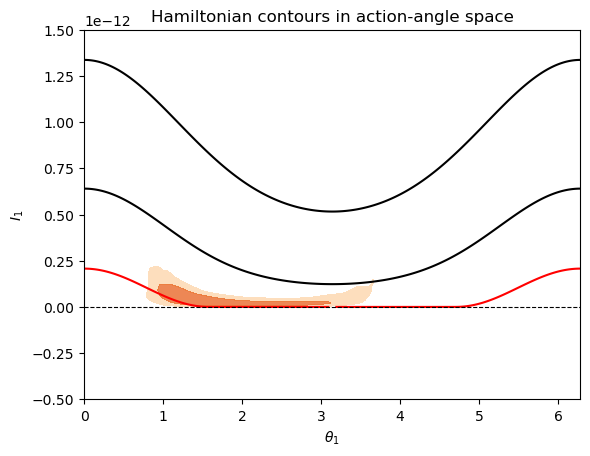

In [35]:
plt.contour(theta1_grid, I1_grid, H_grid, levels=[H_saddle], colors='red',linestyles='-')#, linewidths=2.0)
print(H_saddle)
# contours = plt.contour(theta1_grid, I1_grid, H_grid, levels=50, cmap="viridis")

levels_circulating=[-10.0*10**(-14), -9.5*10**(-14)]
levels_resonant = [-9.2032135*10**(-14)]
plt.contour(theta1_grid, I1_grid, H_grid, levels=levels_circulating, colors='black',linestyles='-')
plt.contour(theta1_grid, I1_grid, H_grid, levels=levels_resonant, colors='green',linestyles='-')



### add Y1 posterior distribution in theta1-I1 space
im_Y1 = Y_1
re_Y1 = X_1
Y_1_complex = re_Y1 + 1j * im_Y1
theta1_back = np.angle(Y_1_complex)  # θ in [-π, π]
I1_back = (np.median(Lambda_c) / 2) * np.abs(Y_1_complex)**2

# Wrap θ into [0, 2π] for cleaner plotting
theta1_back = np.mod(theta1_back, 2 * np.pi)

plt.contourf(theta1_back, I1_back, Z_1, 
             levels=levels_1 + [Z_1.max()], 
             colors=["#fdd0a2", "#e6550d"], 
             alpha=0.7)

import matplotlib.patches as mpatches
# Custom legend patches
orange_1sigma = mpatches.Patch(color="#e6550d", alpha=0.7, label="Y1 (1σ contour)")
orange_2sigma = mpatches.Patch(color="#fdd0a2", alpha=0.7, label="Y1 (2σ contour)")
plt.axhline(0, color='black', linestyle='--', lw=0.8)

# Add legend
# plt.legend(handles=[scatter_pts, orange_1sigma, orange_2sigma], loc="upper right")
# plt.legend(handles=[orange_1sigma, orange_2sigma], loc="upper right")

plt.ylim(-0.5e-12, 1.5e-12)
# plt.legend()
plt.xlabel(r'$\theta_1$')
plt.ylabel(r'$I_1$')
plt.title('Hamiltonian contours in action-angle space')
plt.show()

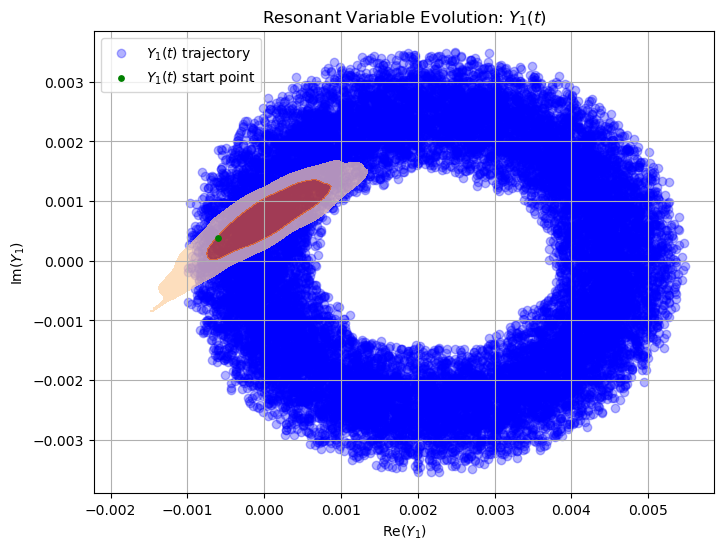

In [36]:
# Plot Y1 in Re/Im space
plt.figure(figsize=(8,6))
plt.scatter(Re_Y1_vals, Im_Y1_vals, c='blue', lw=1, alpha=0.3, label=r'$Y_1(t)$ trajectory')
contour = plt.contourf(X_1, Y_1, Z_1, 
                      levels=levels_1 + [Z_1.max()], 
                      colors=["#fdd0a2", "#e6550d"], 
                      alpha=0.7)
plt.scatter(np.real(Y1i), np.imag(Y1i), c='green', s=15, label=r'$Y_1(t)$ start point')

plt.xlabel(r'Re$(Y_1)$')
plt.ylabel(r'Im$(Y_1)$')
plt.title(r'Resonant Variable Evolution: $Y_1(t)$')
plt.grid(True)
plt.legend()
plt.show()

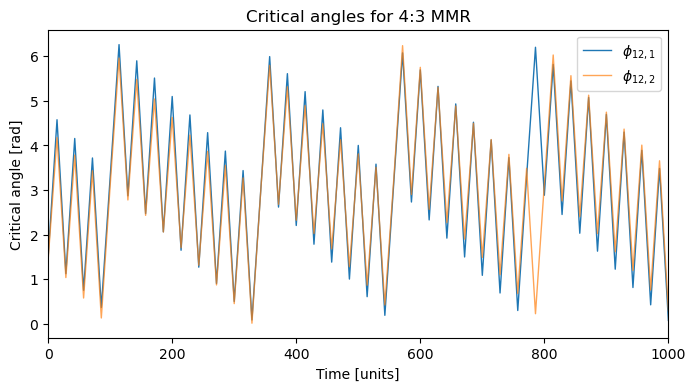

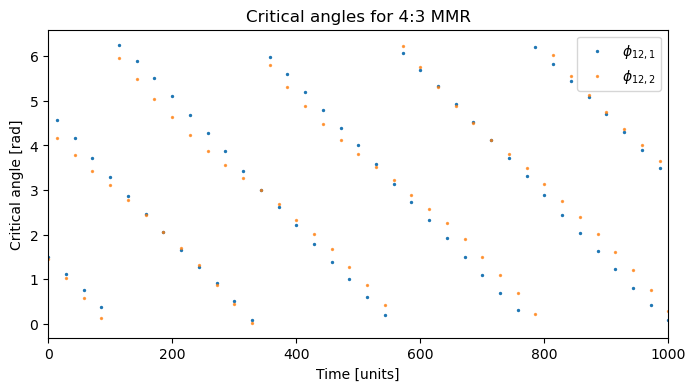

In [37]:
# Wrap angles to [-pi, pi] for easier plotting
phi1_wrapped = (phi1_vals + np.pi) % (2*np.pi) - np.pi
phi2_wrapped = (phi2_vals + np.pi) % (2*np.pi) - np.pi

phi1_wrapped = (phi1_vals) % (2*np.pi)
phi2_wrapped = (phi2_vals) % (2*np.pi)

plt.figure(figsize=(8,4))
plt.plot(times, phi1_wrapped, lw=1, label=r'$\phi_{12,1}$')
plt.plot(times, phi2_wrapped, lw=1, label=r'$\phi_{12,2}$', alpha=0.7)
plt.xlabel("Time [units]")
plt.ylabel("Critical angle [rad]")
plt.legend()
plt.title(f"Critical angles for {p[1]+1}:{p[1]} MMR")
plt.xlim(0,1000)
plt.show()

plt.figure(figsize=(8,4))
plt.scatter(times, phi1_wrapped, s=2, label=r'$\phi_{12,1}$')
plt.scatter(times, phi2_wrapped, s=2, label=r'$\phi_{12,2}$', alpha=0.7)
plt.xlabel("Time [units]")
plt.ylabel("Critical angle [rad]")
plt.legend()
plt.title(f"Critical angles for {p[1]+1}:{p[1]} MMR")
plt.xlim(0,1000)
plt.show()